In [3]:
from matplotlib import pyplot as plt
from pylab import *
import numpy as np
import seaborn as sns
import scipy as sp
import pandas as pd
sys.path.insert(0, '/Users/haly/idefix/pytools')
from vtk_io import *
pi = 3.14






In [4]:
def read_gas(file, Nx, Ny, Nz):
    d = readVTK(file, geometry='cartesian')
    rho_g = d.data.get("RHO")
    vx_g = d.data.get("VX1")
    vy_g = d.data.get("VX2")
    vz_g = d.data.get("VX3")
    rho_g = rho_g.reshape(Nx,Ny,Nz)
    vx_g = vx_g.reshape(Nx,Ny,Nz)
    vy_g = vy_g.reshape(Nx,Ny,Nz)
    vz_g = vz_g.reshape(Nx,Ny,Nz) 
    return rho_g, vx_g, vy_g, vz_g

def read_dust(file, Nx, Ny, Nz):
    d = readVTK(file, geometry='cartesian')
    rho_d = d.data.get("Dust0_RHO")
    vx_d = d.data.get("Dust0_VX1")
    vy_d = d.data.get("Dust0_VX2")
    vz_d = d.data.get("Dust0_VX3")
    rho_d = rho_d.reshape(Nx,Ny,Nz)
    vx_d = vx_d.reshape(Nx,Ny,Nz)
    vy_d = vy_d.reshape(Nx,Ny,Nz)
    vz_d = vz_d.reshape(Nx,Ny,Nz) 
    return rho_d, vx_d, vy_d, vz_d

def read_gas_and_dust(file, Nx, Ny, Nz):
    d = readVTK(file, geometry='cartesian')
    rho_g = d.data.get("RHO")
    vx_g = d.data.get("VX1")
    vy_g = d.data.get("VX2")
    vz_g = d.data.get("VX3")
    rho_g = rho_g.reshape(Nx,Ny,Nz)
    vx_g = vx_g.reshape(Nx,Ny,Nz)
    vy_g = vy_g.reshape(Nx,Ny,Nz)
    vz_g = vz_g.reshape(Nx,Ny,Nz)

    rho_d = d.data.get("Dust0_RHO")
    vx_d = d.data.get("Dust0_VX1")
    vy_d = d.data.get("Dust0_VX2")
    vz_d = d.data.get("Dust0_VX3")
    rho_d = rho_d.reshape(Nx,Ny,Nz)
    vx_d = vx_d.reshape(Nx,Ny,Nz)
    vy_d = vy_d.reshape(Nx,Ny,Nz)
    vz_d = vz_d.reshape(Nx,Ny,Nz)
    return rho_g, vx_g, vy_g, vz_g, rho_d, vx_d, vy_d, vz_d


def read_history(directory):
    f = open(directory, 'r')
    time =  []
    rho_max = []

    for line in f:
        line = line.strip()
        columns = line.split()
        time.append(float(columns[0])) 
        rho_max.append(float(columns[1]))
    f.close()
    return time, rho_max

def calculate_vKE(directory,snapshot,Nx,Nz):
    file    = directory + "/data."+ "{:04d}".format(snapshot) + ".vtk"
    rho_g, vx_g, vy_g, vz_g = read_gas(file, Nx, 1, Nz)
    return (0.5*1./Nz*9.6672/Nx*pi*np.sum(rho_g*vz_g*vz_g))

def calculate_rKE(directory,snapshot,Nx,Nz):
    file    = directory + "/data."+ "{:04d}".format(snapshot) + ".vtk"
    q = -1.48995
    d = readVTK(file, geometry='cartesian')
    rho_g, vx_g, vy_g, vz_g = read_gas(file, Nx, 1, Nz)
    vx_g=vx_g.reshape(Nx,Nz).T
    vy_g=vy_g.reshape(Nx,Nz).T
    rho_g=rho_g.reshape(Nx,Nz).T
    return (1./Nz*9.6672/Nx*pi*np.sum(0.5*rho_g*vx_g*vx_g+2.*rho_g*(vy_g-np.tile(d.x,(Nz,1))*q)**2))

def read_and_plot_gas_FairbairnStone_3D_slice(directory,Nx,Ny,Nz,slice,snapshot,axs,fig):
    file    = directory + "/data."+ "{:04d}".format(snapshot) + ".vtk"
    d = readVTK(file, geometry='cartesian')
    rho_g, vx_g, vy_g, vz_g = read_gas(file, Nx, Ny, Nz)

    q = -1.48995

    print(np.max(rho_g))
    print(np.float64(np.min(rho_g)))

    im1 = axs[0].imshow(rho_g[:,slice,:].T,origin='lower',norm="linear",cmap="mako", aspect='auto')
    fig.colorbar(im1)

    im2 = axs[1].imshow(vx_g[:,slice,:].T,origin='lower',norm="linear",cmap="seismic", aspect='auto', vmin=-0.2, vmax=0.2)
    fig.colorbar(im2)


    im3 = axs[2].imshow(vy_g[:,slice,:].T-np.tile(d.x,(Nz,1))*q,origin='lower',norm="linear",cmap="seismic", aspect='auto', vmin=-0.2, vmax=0.2)
    fig.colorbar(im3)

    im4 = axs[3].imshow(vz_g[:,slice,:].T,origin='lower',norm="linear",cmap="seismic", aspect='auto')
    fig.colorbar(im4)

    axs[0].set_title(r'$\rho_g$')
    axs[1].set_title(r'$V_x$')
    axs[2].set_title(r'$V_y$')
    axs[3].set_title(r'$V_z$')

def read_and_plot_gas_FairbairnStone_3D_integrated_in_y(directory,Nx,Ny,Nz,snapshot,axs,fig):
    file    = directory + "/data."+ "{:04d}".format(snapshot) + ".vtk"
    d = readVTK(file, geometry='cartesian')
    rho_g, vx_g, vy_g, vz_g = read_gas(file, Nx, Ny, Nz)

    print(np.max(rho_g))
    print(np.float64(np.min(rho_g)))
    q = -1.48995
    #q = -1.395

    rho_sum = vx_sum = vy_sum = vz_sum = zeros((Nz,Nx))

    for i in range(0,Ny):
        rho_sum = rho_sum + rho_g[:,i,:].T
        vx_sum = vx_sum + rho_g[:,i,:].T*vx_g[:,i,:].T
        vy_sum = vy_sum + rho_g[:,i,:].T*vy_g[:,i,:].T
        vz_sum = vz_sum + rho_g[:,i,:].T*vz_g[:,i,:].T

    im1 = axs[0].imshow(rho_sum/Ny,origin='lower',norm="linear",cmap="mako", aspect='auto')
    fig.colorbar(im1)

    im2 = axs[1].imshow(vx_sum/rho_sum,origin='lower',norm="linear",cmap="seismic", aspect='auto', vmin=-0.2, vmax=0.2)
    fig.colorbar(im2)


    im3 = axs[2].imshow(vy_sum/rho_sum-np.tile(d.x,(Nz,1))*q,origin='lower',norm="linear",cmap="seismic", aspect='auto', vmin=-0.2, vmax=0.2)
    fig.colorbar(im3)

    im4 = axs[3].imshow(vz_sum/rho_sum,origin='lower',norm="linear",cmap="seismic", aspect='auto')
    fig.colorbar(im4)

    axs[0].set_title(r'$\rho_g$')
    axs[1].set_title(r'$V_x$')
    axs[2].set_title(r'$V_y$')
    axs[3].set_title(r'$V_z$')

def read_and_plot_gas_FairbairnStone_3D_integrated_in_xy(directory,Nx,Ny,Nz,snapshot,axs,fig, colour):
    file    = directory + "/data."+ "{:04d}".format(snapshot) + ".vtk"
    d = readVTK(file, geometry='cartesian')
    rho_g, vx_g, vy_g, vz_g = read_gas(file, Nx, Ny, Nz)
    q = -1.48995

    rho_sum_xy = vx_sum_xy = vy_sum_xy = vz_sum_xy = zeros((Nz))
    rho_sum_y = vx_sum_y = vy_sum_y = vz_sum_y = zeros((Nz,Nx))

    for i in range(0,Ny):
        rho_sum_y = rho_sum_y + rho_g[:,i,:].T
        vx_sum_y = vx_sum_y + rho_g[:,i,:].T*vx_g[:,i,:].T
        vy_sum_y = vy_sum_y + rho_g[:,i,:].T*vy_g[:,i,:].T
        vz_sum_y = vz_sum_y + rho_g[:,i,:].T*vz_g[:,i,:].T

    vx_sum_y = vx_sum_y/rho_sum_y
    vy_sum_y = vy_sum_y/rho_sum_y
    vy_sum_y = vy_sum_y - np.tile(d.x,(Nz,1))*q


    for i in range(0,Nx):
        rho_sum_xy = rho_sum_xy + rho_sum_y[:,i]
        vx_sum_xy = vx_sum_xy + rho_sum_y[:,i]*vx_sum_y[:,i]
        vy_sum_xy = vy_sum_xy + rho_sum_y[:,i]*vy_sum_y[:,i]
        vz_sum_xy = vz_sum_xy + rho_sum_y[:,i]*vz_sum_y[:,i]

    
    im1 = axs[0].plot(vx_sum_xy/rho_sum_xy,d.z,color=colour)
    im2 = axs[1].plot(vy_sum_xy/rho_sum_xy,d.z,color=colour)

    axs[0].set_title(r'$V_x$')
    axs[1].set_title(r'$V_y$')

def read_and_plot_dust_FairbairnStone_3D_slice(directory,Nx,Ny,Nz,slice,snapshot,axs,fig):
    file    = directory + "/data."+ "{:04d}".format(snapshot) + ".vtk"
    d = readVTK(file, geometry='cartesian')
    rho_d, vx_d, vy_d, vz_d = read_dust(file, Nx, Ny, Nz)
    q = -1.48995
    print(np.max(rho_d))
    print(np.float64(np.min(rho_d)))

    im1 = axs[0].imshow(rho_d[:,slice,:].T,origin='lower',norm="log",cmap="mako", aspect='auto', vmin=0.01)
    fig.colorbar(im1)

    im2 = axs[1].imshow(vx_d[:,slice,:].T,origin='lower',norm="linear",cmap="seismic", aspect='auto')
    fig.colorbar(im2)


    im3 = axs[2].imshow(vy_d[:,slice,:].T-np.tile(d.x,(Nz,1))*q,origin='lower',norm="linear",cmap="seismic", aspect='auto')
    fig.colorbar(im3)

    im4 = axs[3].imshow(vz_d[:,slice,:].T,origin='lower',norm="linear",cmap="seismic", aspect='auto')
    fig.colorbar(im4)

    axs[0].set_title(r'$\rho_d$')
    axs[1].set_title(r'$V_x$')
    axs[2].set_title(r'$V_y$')
    axs[3].set_title(r'$V_z$')

def read_and_plot_dust_FairbairnStone_3D_integrated_in_y(directory,Nx,Ny,Nz,q,snapshot,axs,fig):
    file    = directory + "/data."+ "{:04d}".format(snapshot) + ".vtk"
    d = readVTK(file, geometry='cartesian')
    rho_d, vx_d, vy_d, vz_d = read_dust(file, Nx, Ny, Nz)
    
    q = q
    print(np.max(rho_d))
    print(np.float64(np.min(rho_d)))

    rho_sum = vx_sum = vy_sum = vz_sum = zeros((Nz,Nx))

    for i in range(0,Ny):
        rho_sum = rho_sum + rho_d[:,i,:].T
        vx_sum = vx_sum + rho_d[:,i,:].T*vx_d[:,i,:].T
        vy_sum = vy_sum + rho_d[:,i,:].T*vy_d[:,i,:].T
        vz_sum = vz_sum + rho_d[:,i,:].T*vz_d[:,i,:].T

    im1 = axs[0].imshow(rho_sum/Ny,origin='lower',norm="log",cmap="mako", aspect='auto', vmin=0.01)
    fig.colorbar(im1)

    im2 = axs[1].imshow(vx_sum/rho_sum,origin='lower',norm="linear",cmap="seismic", aspect='auto', vmin=-0.2, vmax=0.2)
    fig.colorbar(im2)

    im3 = axs[2].imshow(vy_sum/rho_sum-np.tile(d.x,(Nz,1))*q,origin='lower',norm="linear",cmap="seismic", aspect='auto', vmin=-0.2, vmax=0.2)
    fig.colorbar(im3)

    im4 = axs[3].imshow(vz_sum/rho_sum,origin='lower',norm="linear",cmap="seismic", aspect='auto')
    fig.colorbar(im4)

    axs[0].set_title(r'$\rho_d$')
    axs[1].set_title(r'$V_x$')
    axs[2].set_title(r'$V_y$')
    axs[3].set_title(r'$V_z$')


def read_and_plot_dust_FairbairnStone_3D_integrated_in_z(directory,Nx,Ny,Nz,snapshot,axs,fig):
    file    = directory + "/data."+ "{:04d}".format(snapshot) + ".vtk"
    d = readVTK(file, geometry='cartesian')
    rho_d, vx_d, vy_d, vz_d = read_dust(file, Nx, Ny, Nz)
    q = -1.48995
    print(np.max(rho_d))
    print(np.float64(np.min(rho_d)))

    rho_sum = vx_sum = vy_sum = vz_sum = zeros((Ny,Nx))

    for i in range(0,Nz):
        rho_sum = rho_sum + rho_d[:,:,i].T
        vx_sum = vx_sum + rho_d[:,:,i].T*vx_d[:,:,i].T
        vy_sum = vy_sum + rho_d[:,:,i].T*vy_d[:,:,i].T
        vz_sum = vz_sum + rho_d[:,:,i].T*vz_d[:,:,i].T

    im1 = axs[0].imshow(rho_sum/Nz,origin='lower',norm="log",cmap="mako", aspect='auto', vmin=0.01)
    fig.colorbar(im1)

    im2 = axs[1].imshow(vx_sum/rho_sum,origin='lower',norm="linear",cmap="seismic", aspect='auto')
    fig.colorbar(im2)


    im3 = axs[2].imshow(vy_sum/rho_sum-np.tile(d.x,(Ny,1))*q,origin='lower',norm="linear",cmap="seismic", aspect='auto')
    fig.colorbar(im3)

    im4 = axs[3].imshow(vz_sum/rho_sum,origin='lower',norm="linear",cmap="seismic", aspect='auto')
    fig.colorbar(im4)

    axs[0].set_title(r'$\rho_d$')
    axs[1].set_title(r'$V_x$')
    axs[2].set_title(r'$V_y$')
    axs[3].set_title(r'$V_z$')



def read_and_plot_dust_and_gas_integrated_in_y(directory,Nx,Ny,Nz,snapshot,axs,fig,font,tick_font=16,vscale=1.0):
    file    = directory + "/data."+ "{:04d}".format(snapshot) + ".vtk"
    d = readVTK(file, geometry='cartesian')
    rho_g, vx_g, vy_g, vz_g = read_gas(file, Nx, Ny, Nz)
    rho_d, vx_d, vy_d, vz_d = read_dust(file, Nx, Ny, Nz)
    q = -1.48995
    print(np.max(rho_d))
    print(np.float64(np.min(rho_d)))

    print(np.max(rho_g))
    print(np.float64(np.min(rho_g)))


    rho_sum_d = vx_sum_d = vy_sum_d = vz_sum_d = zeros((Nz,Nx))
    rho_sum_g = vx_sum_g = vy_sum_g = vz_sum_g = zeros((Nz,Nx))

    for i in range(0,Ny):
        rho_sum_d = rho_sum_d + rho_d[:,i,:].T
        vx_sum_d = vx_sum_d + rho_d[:,i,:].T*vx_d[:,i,:].T
        vy_sum_d = vy_sum_d + rho_d[:,i,:].T*vy_d[:,i,:].T
        vz_sum_d = vz_sum_d + rho_d[:,i,:].T*vz_d[:,i,:].T
        rho_sum_g = rho_sum_g + rho_g[:,i,:].T
        vx_sum_g = vx_sum_g + rho_g[:,i,:].T*vx_g[:,i,:].T
        vy_sum_g = vy_sum_g + rho_g[:,i,:].T*vy_g[:,i,:].T
        vz_sum_g = vz_sum_g + rho_g[:,i,:].T*vz_g[:,i,:].T

    im1 = axs[0][0].imshow(rho_sum_g/Ny,origin='lower',norm="log",cmap="mako", aspect='auto', vmin=0.01, vmax=10)
    cbar = fig.colorbar(im1, location='left', fraction=0.02, pad=0.02)
    cbar.ax.tick_params(labelsize=tick_font)

    im2 = axs[1][0].imshow(vx_sum_g/rho_sum_g,origin='lower',norm="linear",cmap="seismic", aspect='auto', vmin=-vscale, vmax=vscale)
    cbar = fig.colorbar(im2, location='left', fraction=0.02, pad=0.02)
    cbar.ax.tick_params(labelsize=tick_font)

    im3 = axs[2][0].imshow(vz_sum_g/rho_sum_g,origin='lower',norm="linear",cmap="seismic", aspect='auto', vmin = -vscale,vmax=vscale )
    cbar = fig.colorbar(im3, location='left', fraction=0.02, pad=0.02)
    cbar.ax.tick_params(labelsize=tick_font)

    im4 = axs[0][1].imshow(rho_sum_d/Ny,origin='lower',norm="log",cmap="mako", aspect='auto', vmin=0.01, vmax=10)
    cbar = fig.colorbar(im4, location='right', fraction=0.02, pad=0.02)
    cbar.ax.tick_params(labelsize=tick_font)

    im5 = axs[1][1].imshow(vx_sum_d/rho_sum_d,origin='lower',norm="linear",cmap="seismic", aspect='auto', vmin=-vscale, vmax=vscale)
    cbar = fig.colorbar(im5, location='right', fraction=0.02, pad=0.02)
    cbar.ax.tick_params(labelsize=tick_font)

    im6 = axs[2][1].imshow(vz_sum_d/rho_sum_d,origin='lower',norm="linear",cmap="seismic", aspect='auto', vmin = -vscale,vmax=vscale)
    cbar = fig.colorbar(im6, location='right', fraction=0.02, pad=0.02)
    cbar.ax.tick_params(labelsize=tick_font)



    axs[0][0].set_title(r'$\rho_g$',font)
    axs[1][0].set_title(r'$u_g$',font)
    axs[2][0].set_title(r'$w_g$',font)
    axs[0][1].set_title(r'$\rho_d$',font)
    axs[1][1].set_title(r'$u_d$',font)
    axs[2][1].set_title(r'$w_d$',font)

    for i in range(0,3):
        for j in range(0,2):
            axs[i][j].set_xticks([])
            axs[i][j].set_yticks([])

    



# 2 fluid equations

\begin{equation}
\frac{\partial \mathbf{u}_g}{\partial t}+\mathbf{u}_g \cdot \nabla \mathbf{u}_g + 2\mathbf{\Omega} \times \mathbf{u}_g = 2 \Omega S x \mathbf{\hat{x}} - \frac{\nabla P}{\rho_g} + \frac{\rho_d}{\rho_g}\frac{\mathbf{u}_d-\mathbf{u}_g}{t_s} + F_w \mathbf{\hat{x}}
\end{equation}

\begin{equation}
\frac{\partial \mathbf{u}_d}{\partial t}+\mathbf{u}_d \cdot \nabla \mathbf{u}_d + 2\mathbf{\Omega} \times \mathbf{u}_d = 2 \Omega S x \mathbf{\hat{x}} + \frac{\mathbf{u}_d-\mathbf{u}_g}{t_s} 
\end{equation}

\begin{align}
&u_g = u_{b,g} \Omega z\\
&v_g = v_{b,g} \Omega z - S x\\
&u_d = u_{b,d} \Omega z\\
&v_d = v_{b,d} \Omega z - S x
\end{align}

\begin{equation}
\frac{\partial u_{b,g}}{\partial t} - 2 \Omega v_{b,g} = \frac{f}{t_s}(u_{b,d}-u_{b,g})+\psi \Omega e^{i\Omega t}
\end{equation}

\begin{equation}
\frac{\partial v_{b,g}}{\partial t} + \frac{\kappa^2}{2\Omega}u_{b,g} = \frac{f}{t_s} (v_{b,d}-v_{b,g})
\end{equation}

\begin{equation}
\frac{\partial u_{b,d}}{\partial t} - 2 \Omega v_{b,d} = -\frac{1}{t_s} (u_{b,d}-u_{b,g})
\end{equation}

\begin{equation}
\frac{\partial v_{b,d}}{\partial t} + \frac{\kappa^2}{2\Omega}u_{b,d} = -\frac{1}{t_s} (v_{b,d}-v_{b,g})
\end{equation}

\begin{align}
&u_{b,g} = \mathrm{Re}\left[ \psi \Omega t_s \left(        \frac{i\Omega t_s(\beta+\gamma)+f\beta}{\beta(\beta+\gamma(1+f))}     \right) e^{i \Omega t}\right]\\
&v_{b,g} = \mathrm{Re}\left[ -\frac{1}{2}\psi \kappa^2 t_s^2 \left(        \frac{\beta+\gamma}{\beta(\beta+\gamma(1+f))}     \right) e^{i \Omega t}\right]\\
&u_{b,d} = \mathrm{Re}\left[ \psi \Omega t_s \left(        \frac{\beta-i\Omega t_s\gamma}{\beta(\beta+\gamma(1+f))}     \right) e^{i \Omega t}\right]\\
&v_{b,d} = \mathrm{Re}\left[ -\frac{1}{2}\psi \kappa^2 t_s^2 \left(        \frac{\gamma}{\beta(\beta+\gamma(1+f))}     \right) e^{i \Omega t}\right]
\end{align}

with $\beta=t_s^2(\kappa^2-\Omega^2)$ and $\gamma=2i\Omega t_s+1+f$

# Barycentric velocity formulation
The Barycentric and drift velocity vectors are defined as $\mathbf{V = \frac{\rho_g \mathbf{u}_g+\rho_d\mathbf{u}_d}{\rho}}$ and $\Delta \mathbf{V} = \mathbf{u}_d-\mathbf{u}_g$

\begin{equation}
\frac{\partial \mathbf{V}}{\partial t} + \mathbf{V}\cdot \nabla \mathbf{V} + \mathbf{F}(\Delta \mathbf{V}^2) + 2\mathbf{\Omega} \times \mathbf{V} = 2\Omega S x \hat{x} - \frac{\nabla P}{\rho} + \frac{\rho_g}{\rho} F_w \hat{x}
\end{equation}

\begin{equation}
\frac{\partial \mathbf{\Delta V}}{\partial t} + \mathbf{V}\cdot \nabla \mathbf{\Delta V} + \Delta \mathbf{V} \cdot \nabla \mathbf{V}  + \mathbf{G}(\Delta \mathbf{V}^2) +2\mathbf{\Omega} \times \Delta \mathbf{V} = - \frac{\rho}{\rho_g}\frac{\Delta V}{t_s} + \frac{\nabla P}{\rho_g}- F_w \hat{x}
\end{equation}

\begin{equation}
\frac{\mathrm{d}U_b}{\mathrm{d}t}-2\Omega V_b = \frac{\Omega}{1+f}\psi e^{i\Omega t}
\end{equation}

\begin{equation}
\frac{\mathrm{d}V_b}{\mathrm{d}t}+\frac{\kappa^2}{2\Omega} U_b=0
\end{equation}

\begin{equation}
\frac{\mathrm{d}\Delta U_b}{\mathrm{d}t} - 2\Omega \Delta V_b = - \frac{1+f}{t_s} \Delta U_b - \psi \Omega e^{i\Omega t}
\end{equation}

\begin{equation}
\frac{\mathrm{d}\Delta V_b}{\mathrm{d}t} + \frac{\kappa^2}{2\Omega} \Delta U_b = - \frac{1+f}{t_s} \Delta V_b
\end{equation}

The homogeneous solution is:

\begin{equation}
U_b = \mathrm{Re} \left[e^{\pm i \kappa t} \right]
\end{equation}

\begin{equation}
V_b = \mathrm{Re} \left[ \pm \frac{i \kappa}{2\Omega} e^{\pm i \kappa t} \right]
\end{equation}

\begin{equation}
\Delta U_b = \mathrm{Re} \left[e^{(\pm i \kappa - \sigma_{damp})t} \right]
\end{equation}

\begin{equation}
\Delta V_b = \mathrm{Re} \left[\pm \frac{i \kappa}{2\Omega}e^{(\pm i \kappa - \sigma_{damp})t} \right]
\end{equation}

The inhomogeneous solution is:

\begin{equation}
U_b = \mathrm{Re} \left[i \frac{\psi \Omega^2}{(1+f)(\kappa^2-\Omega^2)} e^{i\Omega t}\right]
\end{equation}

\begin{equation}
V_b = \mathrm{Re} \left[-\frac{\kappa^2}{2\Omega^2} \frac{\psi \Omega^2}{(1+f)(\kappa^2-\Omega^2)} e^{i\Omega t}\right]
\end{equation}

\begin{equation}
\Delta U_b = \mathrm{Re} \left[\xi \Omega z (1-i\frac{\sigma_{damp}}{\Omega})e^{i\Omega t}\right]
\end{equation}

\begin{equation}
\Delta V_b = \mathrm{Re} \left[-\xi \Omega z \frac{\kappa^2}{2\Omega^2}e^{i\Omega t}\right]
\end{equation}

with $\xi = - \frac{\psi \Omega^2}{(\kappa^2-\Omega^2)+i2\Omega \sigma_{damp}+\sigma_{damp}^2}$

1.7691766
0.638738751411438
1.9777534
0.5540760159492493
2.042715
0.605476438999176
1.7107128
0.5671109557151794
2.121047
0.6053589582443237
1.9126979
0.588589608669281
1.6605881
0.5558780431747437


(-0.225, 0.2255)

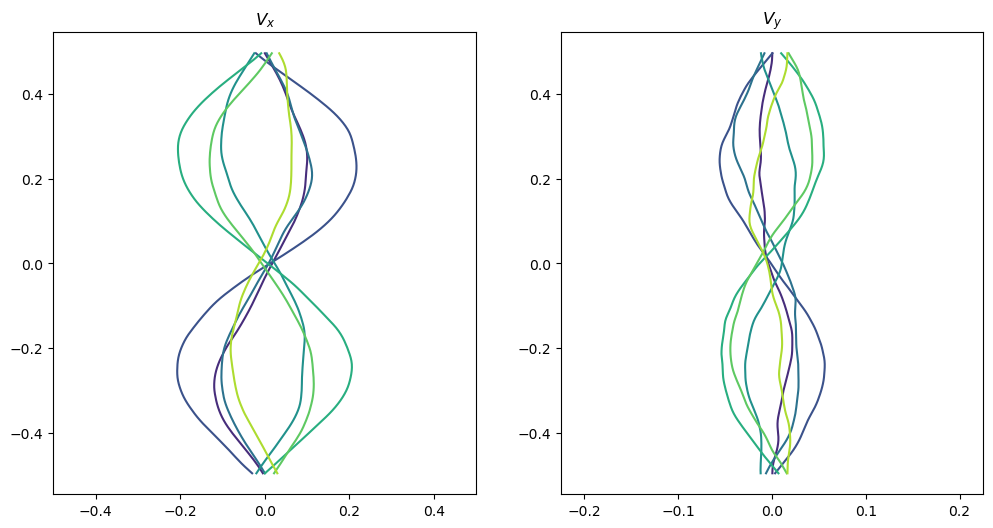

In [190]:
plt.rcParams["figure.figsize"] = (12,6)
fig, axs = plt.subplots(1,2)

#directory = "/Users/haly/science/projects/local_warp/Fairbairn&Stone_gas_only_3D"
directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/FairbairnStone_gas_only_3D"




Nx = 1232
Ny = 100
Nz = 128
slice = 30
colour = sns.color_palette("viridis",7)
snapshot = 251

for i in range(0,7):
    read_and_plot_gas_FairbairnStone_3D_integrated_in_xy(directory,Nx,Ny,Nz,snapshot+i,axs,fig,colour[i])


axs[0].set_xlim(-0.5,0.5)
axs[1].set_xlim(-0.225,0.2255)

In [63]:
plt.rcParams["figure.figsize"] = (20,10)

#directory = "/Users/haly/science/projects/local_warp/Fairbairn&Stone_gas_only_3D"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/FairbairnStone_gas_only_3D"

#directory = "/Users/haly/science/projects/local_warp/shear_3D/zero_gradient"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/shear_3D/zero_gradient"
#directory = "/Users/haly/science/projects/local_warp/shear_3D/non_reflective"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/shear_3D/non_reflective"
#directory = "/Users/haly/science/projects/local_warp/shear_3D/extrapolate"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/shear_3D/extrapolate"
#directory = "/Users/haly/science/projects/local_warp/shear_3D/reverse_periodic"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/shear_3D/reverse_periodic"
#directory = "/Users/haly/science/projects/local_warp/shear_3D/reverse_periodic_shear_corrected"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/shear_3D/reverse_periodic_shear_corrected"
#directory = "/Users/haly/science/projects/local_warp/shear_3D/non_reflective_consistent"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/shear_3D/non_reflective_consistent"

#directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic"
directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/low_detuning"


#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/noDomainDecomposition"



Nx = 1232
Ny = 1
Nz = 128
slice = 1

with plt.ioff():
    for i in range(0,628):
        fig, axs = plt.subplots(3,2)
        plt.subplots_adjust(wspace=0.01,hspace=0.1)

        im = read_and_plot_dust_and_gas_integrated_in_y(directory,Nx,Ny,Nz,i,axs,fig)
        plt.savefig('new_image_'+"{:04d}".format(i)+".png", bbox_inches='tight', pad_inches=0) 
        plt.close()


0.2
0.20000000298023224
0.2061871
0.19428659975528717
0.21127003
0.19057682156562805
0.21479465
0.18875981867313385
0.21679516
0.1877795308828354
0.21754095
0.18552082777023315
0.219988
0.18361467123031616
0.2233993
0.1823837012052536
0.2251257
0.18189938366413116
0.22558743
0.1808864176273346
0.2279823
0.17948366701602936
0.2297689
0.17847208678722382
0.23079404
0.17774498462677002
0.23164031
0.17689219117164612
0.23297508
0.17577330768108368
0.23416767
0.17458206415176392
0.2365705
0.17349912226200104
0.23916681
0.17258381843566895
0.2413063
0.17176620662212372
0.2428728
0.1711011677980423
0.2438149
0.1706676334142685
0.24406971
0.1705743372440338
0.24358921
0.17095813155174255
0.24240251
0.1715449094772339
0.24048172
0.170775905251503
0.2404948
0.17026950418949127
0.24109933
0.1701502799987793
0.24115652
0.17058491706848145
0.2405107
0.1715029925107956
0.23916298
0.17105183005332947
0.23787548
0.17087355256080627
0.2384815
0.17110943794250488
0.23873565
0.17193260788917542
0.2385812

1.3939441
0.6513233184814453


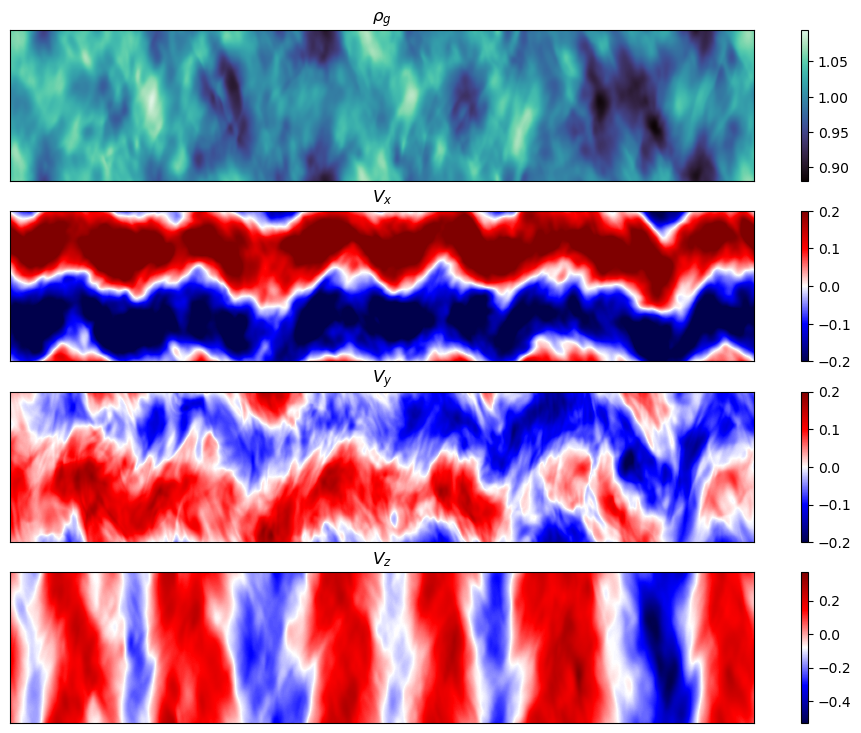

In [88]:
plt.rcParams["figure.figsize"] = (12,9)
fig, axs = plt.subplots(4,1)

#directory = "/Users/haly/science/projects/local_warp/Fairbairn&Stone"


directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/FairbairnStone_dust_3D"

snapshot =1200
Nx = 1232
Ny = 100
Nz = 128
slice = 50

#read_and_plot_dust_FairbairnStone_3D_slice(directory,Nx,Ny,Nz,slice,snapshot,axs,fig)
read_and_plot_gas_FairbairnStone_3D_integrated_in_y(directory,Nx,Ny,Nz,snapshot,axs,fig)
for i in [0,1,2,3]:
    axs[i].set_xticks([])
    axs[i].set_yticks([])
plt.show()
plt.close()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


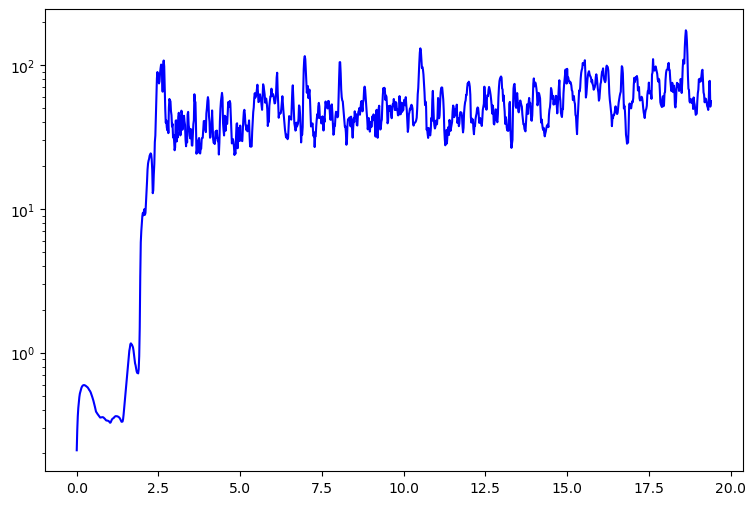

In [135]:
plt.rcParams["figure.figsize"] = (9,6)
fig,ax = plt.subplots(1,1)
directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/FairbairnStone_dust_3D"


time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="blue")




ax.legend( loc='best', frameon=False, fontsize=12)

ax.set_yscale('log')
#ax.set_xlim(0,10)

0.40376353
3.3602005714783445e-05


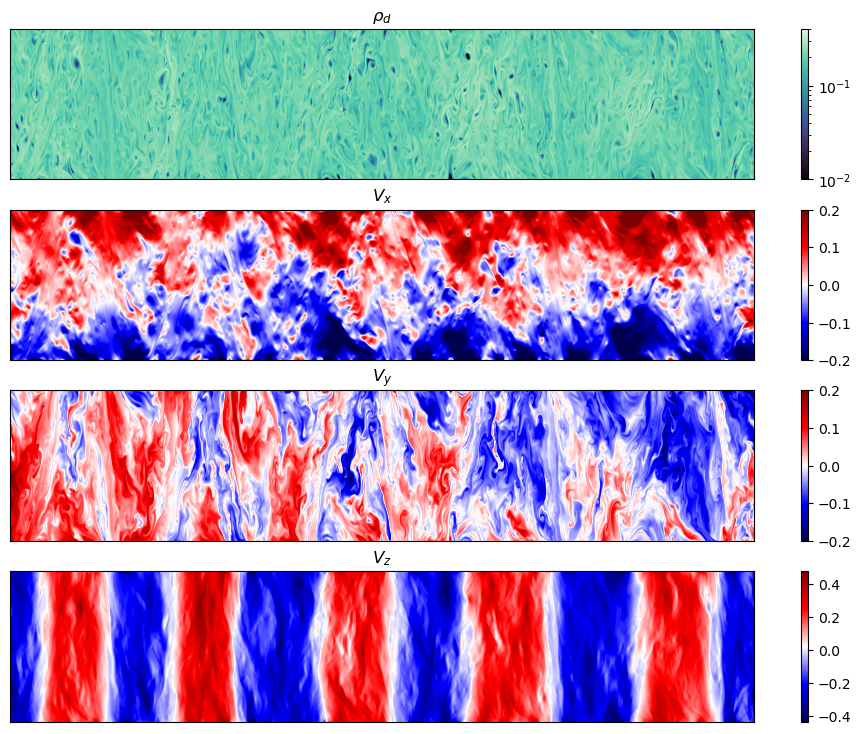

In [340]:
plt.rcParams["figure.figsize"] = (12,9)
fig, axs = plt.subplots(4,1)
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/shear_3D/non_reflective"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/shear_3D/non_reflective_consistent"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/shear_3D/reverse_periodic"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/shear_3D/reverse_periodic_consistent"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/shear_3D/reverse_periodic_shear_corrected"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/shear_3D/zero_gradient"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/shear_3D/extrapolate"

#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/shear_3D/zero_gradient/low_detuning"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/shear_3D/non_reflective_consistent/low_detuning"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/shear_3D/non_reflective/low_detuning"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/shear_3D/reverse_periodic/low_detuning"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/3D"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/noDomainDecomposition"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/kappa0.1"
directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/dust_parameters/st0.01"




snapshot = 252
Nx = 4928
Ny = 1
Nz = 512
slice = 1
#q= -1.395
q = -1.48995

#read_and_plot_dust_FairbairnStone_3D_slice(directory,Nx,Ny,Nz,slice,snapshot,axs,fig)
read_and_plot_dust_FairbairnStone_3D_integrated_in_y(directory,Nx,Ny,Nz,q,snapshot,axs,fig)
#read_and_plot_dust_and_gas_integrated_in_y(directory,Nx,Ny,Nz,snapshot,axs,fig)
for i in [0,1,2,3]:
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()

19.75404
1.2170059164333165e-18


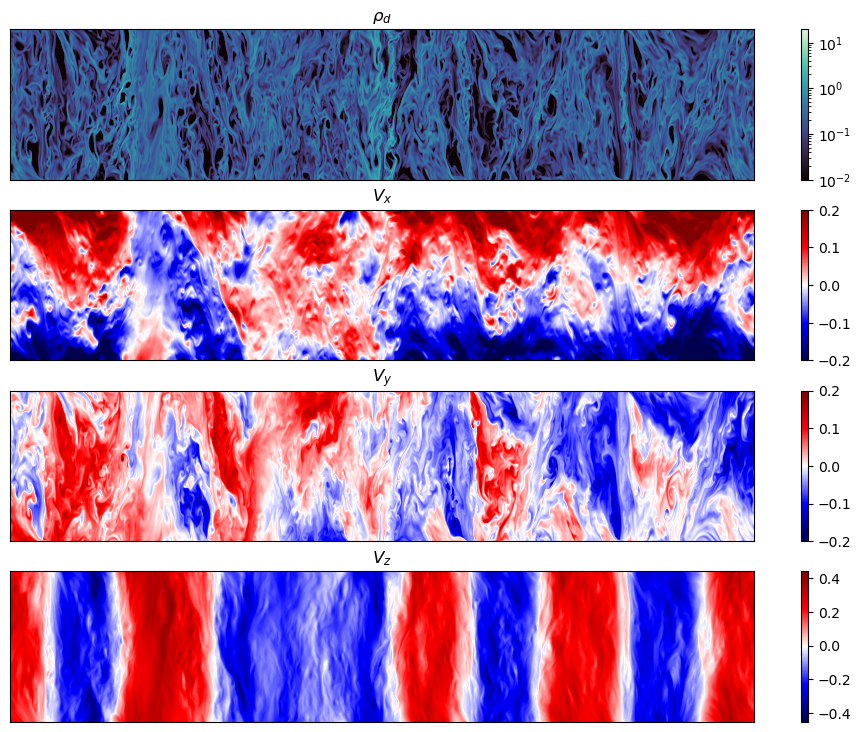

In [341]:
plt.rcParams["figure.figsize"] = (12,9)
fig, axs = plt.subplots(4,1)

#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/shear_3D/non_reflective"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/shear_3D/reverse_periodic"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/shear_3D/zero_gradient"

#directory = "/Users/haly/science/projects/local_warp/shear_3D/zero_gradient"
#directory = "/Users/haly/science/projects/local_warp/shear_3D/non_reflective"
#directory = "/Users/haly/science/projects/local_warp/shear_3D/zero_gradient/low_detuning"
#directory = "/Users/haly/science/projects/local_warp/shear_3D/extrapolate"
#directory = "/Users/haly/science/projects/local_warp/shear_3D/reverse_periodic"
#directory = "/Users/haly/science/projects/local_warp/shear_3D/reverse_periodic_consistent"
#directory = "/Users/haly/science/projects/local_warp/shear_3D/reverse_periodic_shear_corrected"
#directory = "/Users/haly/science/projects/local_warp/shear_3D/non_reflective_consistent"


#directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic"
#directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/high_res_256"
#directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/low_detuning"
#directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/low_detuning/nz512nx2464"
#directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/low_detuning/high_res_256"

#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/newBC"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/noDomainDecomposition"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/nz512nx2464"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/nz256nx4928"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/no_feedback"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/kappa0.1"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/psi0.5"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/psi0.02"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/psi0.004"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/psi0.004kappa0.001"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/dust_parameters/st0.01"
directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/dust_parameters/st0.1"




snapshot = 252
Nx = 4928
Ny = 1
Nz = 512
slice = 1
q = -1.48995
#read_and_plot_gas_FairbairnStone_3D_slice(directory,Nx,Ny,Nz,slice,snapshot,axs,fig)
read_and_plot_dust_FairbairnStone_3D_integrated_in_y(directory,Nx,Ny,Nz,q,snapshot,axs,fig)
for i in [0,1,2,3]:
    axs[i].set_xticks([])
    axs[i].set_yticks([])
plt.show()

(0.0, 30.0)

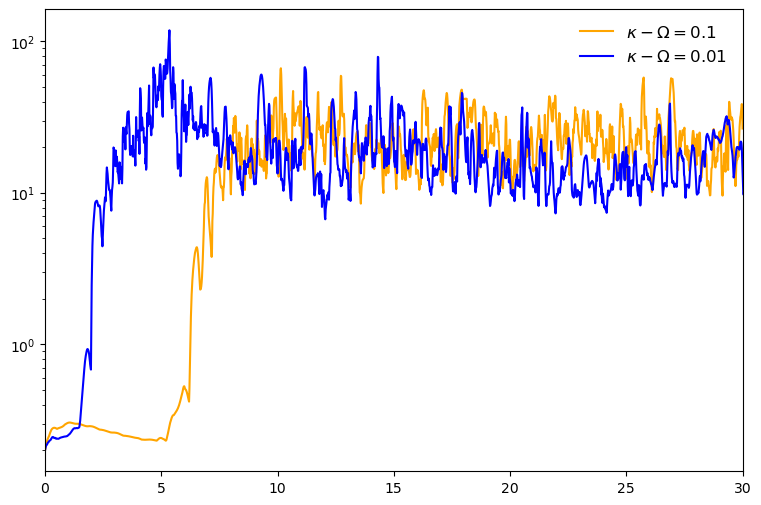

In [711]:
plt.rcParams["figure.figsize"] = (9,6)
fig,ax = plt.subplots(1,1)

directory = "/Users/haly/science/projects/local_warp/shear_3D/non_reflective"
time, dens_dust = read_history(directory+"/timevol.dat")
#ax.plot(np.multiply(time,1./2./pi),dens_dust,color="blue", label="non reflective")



##########################################################################################


directory = "/Users/haly/science/projects/local_warp/shear_3D/zero_gradient"
time, dens_dust = read_history(directory+"/timevol.dat")
#ax.plot(np.multiply(time,1./2./pi),dens_dust,color="orange", label = "zero gradient")



###########################################################################################

directory = "/Users/haly/science/projects/local_warp/shear_3D/extrapolate"
time, dens_dust = read_history(directory+"/timevol.dat")
#ax.plot(np.multiply(time,1./2./pi),dens_dust,color="red", label="extrapolate")



###########################################################################################

directory = "/Users/haly/science/projects/local_warp/shear_3D/reverse_periodic"
time, dens_dust = read_history(directory+"/timevol.dat")
#ax.plot(np.multiply(time,1./2./pi),dens_dust,color="green", label="reverse periodic")

###########################################################################################

directory = "/Users/haly/science/projects/local_warp/shear_3D/reverse_periodic_shear_corrected"
time, dens_dust = read_history(directory+"/timevol.dat")
#ax.plot(np.multiply(time,1./2./pi),dens_dust,color="black", label="reverse periodic corrected")

###########################################################################################


directory = "/Users/haly/science/projects/local_warp/shear_3D/reverse_periodic_consistent"
time, dens_dust = read_history(directory+"/timevol.dat")
#ax.plot(np.multiply(time,1./2./pi),dens_dust,color="cyan", label="reverse periodic consistent")

###########################################################################################


directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="orange", label=r"$\kappa-\Omega=0.1$")

###########################################################################################


directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/low_detuning"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="blue", label=r"$\kappa-\Omega=0.01$")

###########################################################################################


directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/high_res_256"
time, dens_dust = read_history(directory+"/timevol.dat")
#ax.plot(np.multiply(time,1./2./pi),dens_dust,color="darkblue", label="2D reverse periodic")


ax.legend( loc='best', frameon=False, fontsize=12)

ax.set_yscale('log')
ax.set_xlim(0,30)

(0.0, 30.0)

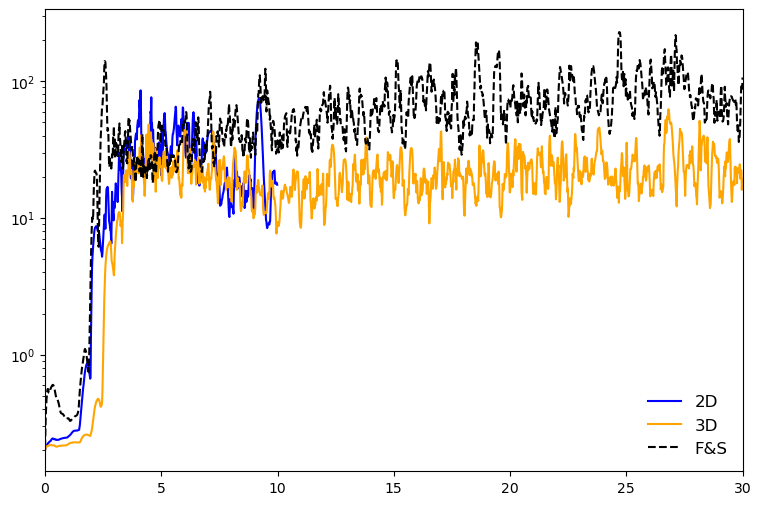

In [ ]:
plt.rcParams["figure.figsize"] = (9,6)
fig,ax = plt.subplots(1,1)


directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/low_detuning"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="blue", label="2D")

###########################################################################################

directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/numerical_parameters/3D"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="orange", label="3D")
###########################################################################################

directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/numerical_parameters/FandS"
time, dens_dust = read_history(directory+"/timevol.dat")
#ax.plot(np.multiply(time,1./2./pi),dens_dust,color="black", linestyle="--", label="F&S")



ax.legend( loc='best', frameon=False, fontsize=12)

ax.set_yscale('log')
ax.set_xlim(0,30)

(0.0, 30.0)

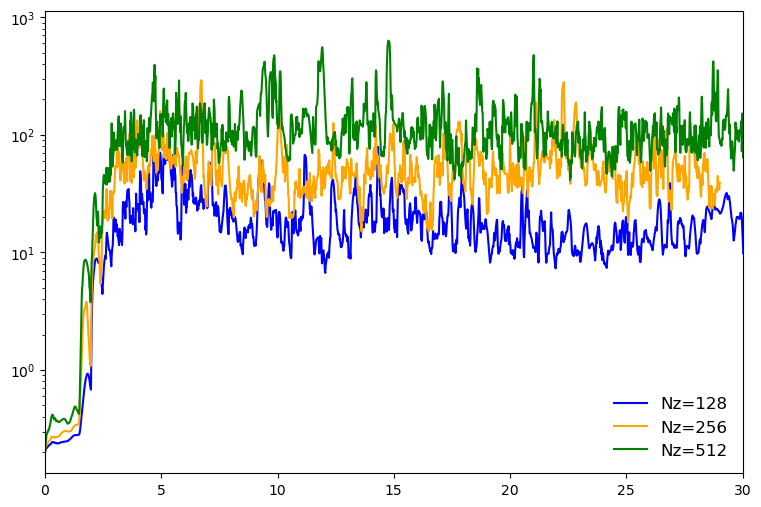

In [92]:
plt.rcParams["figure.figsize"] = (9,6)
fig,ax = plt.subplots(1,1)


directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/low_detuning"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="blue", label="Nz=128")

###########################################################################################
directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/low_detuning/high_res_256"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="orange", label="Nz=256")



###########################################################################################

directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/noDomainDecomposition"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="green", label = "Nz=512")



ax.legend( loc='best', frameon=False, fontsize=12)

ax.set_yscale('log')
ax.set_xlim(0,30)

(0.0, 30.0)

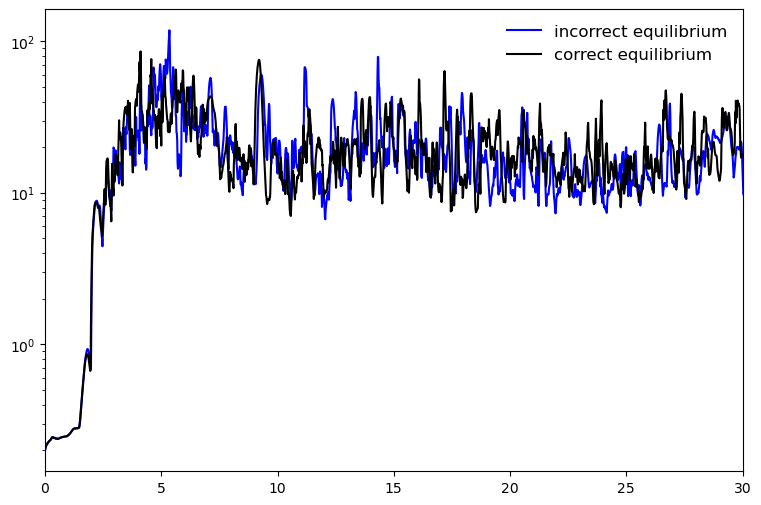

In [14]:
plt.rcParams["figure.figsize"] = (9,6)
fig,ax = plt.subplots(1,1)




directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/low_detuning"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="blue", label="incorrect equilibrium")

directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/low_detuning/correct_equilibrium"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="black", label="correct equilibrium")

ax.legend( loc='best', frameon=False, fontsize=12)

ax.set_yscale('log')
ax.set_xlim(0,30)

(0.0, 40.0)

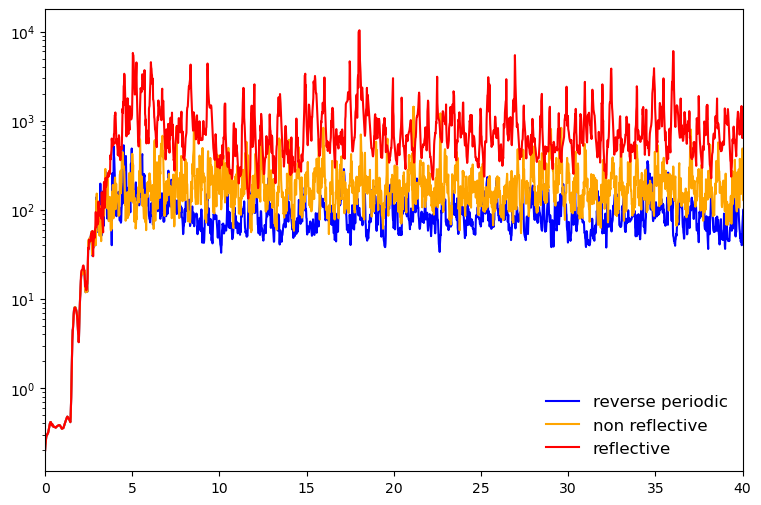

In [42]:
plt.rcParams["figure.figsize"] = (9,6)
fig,ax = plt.subplots(1,1)


directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/noDomainDecomposition"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="blue", label = "reverse periodic")


##########################################################################################


directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/numerical_parameters/BCs/non-reflective"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="orange", label = "non reflective")


###########################################################################################

#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/numerical_parameters/BCs/extrapolate"
#time, dens_dust = read_history(directory+"/timevol.dat")
#ax.plot(np.multiply(time,1./2./pi),dens_dust,color="red", label="extrapolate")

###########################################################################################


#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/numerical_parameters/BCs/non_reflcetive_non_periodic"
#time, dens_dust = read_history(directory+"/timevol.dat")
#ax.plot(np.multiply(time,1./2./pi),dens_dust,color="green", label = "non reflective np")


###########################################################################################


#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/numerical_parameters/BCs/non_reflective_periodic_in_rho"
#time, dens_dust = read_history(directory+"/timevol.dat")
#ax.plot(np.multiply(time,1./2./pi),dens_dust,color="black", label = "non reflective p in rho")


###########################################################################################


directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/numerical_parameters/BCs/reflective"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="red", label = "reflective")



ax.legend( loc='best', frameon=False, fontsize=12)

ax.set_yscale('log')
ax.set_xlim(0,40)

(0.0, 40.0)

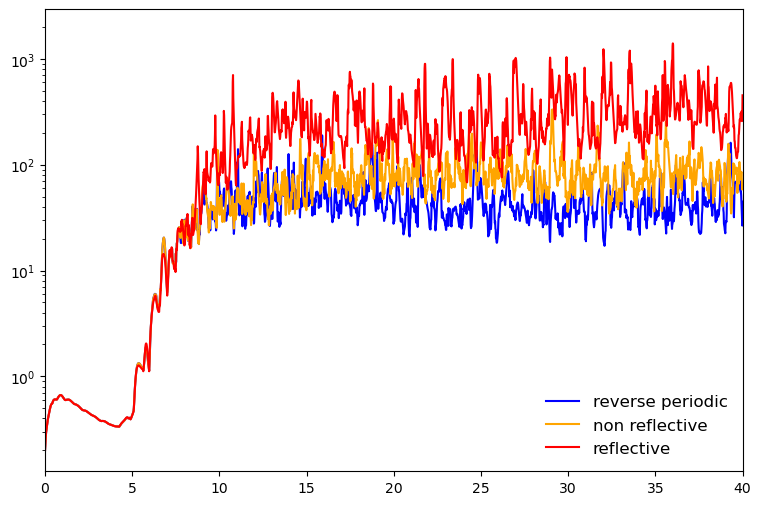

In [103]:
plt.rcParams["figure.figsize"] = (9,6)
fig,ax = plt.subplots(1,1)


directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/psi0.02"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="blue", label = "reverse periodic")


##########################################################################################


directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/numerical_parameters/BCs/non_reflective_psi0.02"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="orange", label = "non reflective")


##########################################################################################

directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/numerical_parameters/BCs/reflective_psi0.02"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="red", label = "reflective")


##########################################################################################

ax.legend( loc='best', frameon=False, fontsize=12)

ax.set_yscale('log')
ax.set_xlim(0,40)

(0.0, 100.0)

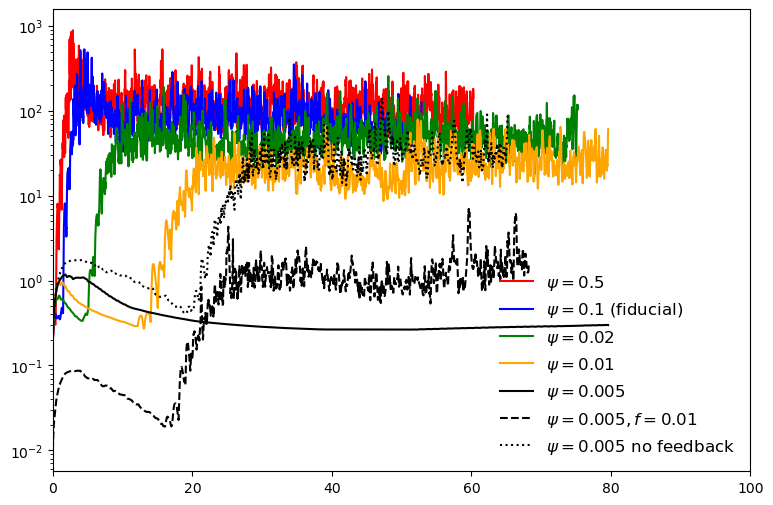

In [107]:
plt.rcParams["figure.figsize"] = (9,6)
fig,ax = plt.subplots(1,1)



directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/kappa0.1"
time, dens_dust = read_history(directory+"/timevol.dat")
#ax.plot(np.multiply(time,1./2./pi),dens_dust,color="orange", label = r"$\kappa-\Omega=0.1$")


###########################################################################################

directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/psi0.5"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="red", label=r"$\psi=0.5$")

###########################################################################################
directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/noDomainDecomposition"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="blue", label = r"$\psi=0.1$ (fiducial)")


##########################################################################################

directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/psi0.02"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="green", label=r"$\psi=0.02$")

##########################################################################################

directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/psi0.01"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="orange", label=r"$\psi=0.01$")

##########################################################################################

directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/psi0.005"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="black", label=r"$\psi=0.005$")

###########################################################################################

#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/psi0.004"
#time, dens_dust = read_history(directory+"/timevol.dat")
#ax.plot(np.multiply(time,1./2./pi),dens_dust,color="cyan", label=r"$\psi=0.004$")

###########################################################################################

directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/psi0.005_f0.01"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="black", linestyle="dashed",label=r"$\psi=0.005,f=0.01$")


##########################################################################################

directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/psi0.005_no_feedback"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="black", linestyle="dotted",label=r"$\psi=0.005$ no feedback")


ax.legend( loc='best', frameon=False, fontsize=12)

ax.set_yscale('log')
ax.set_xlim(0,100)

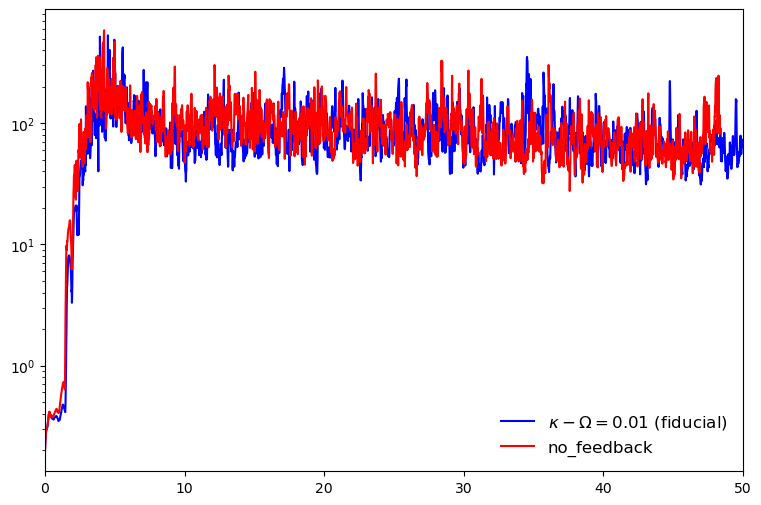

In [ ]:
plt.rcParams["figure.figsize"] = (9,6)
fig,ax = plt.subplots(1,1)

#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/noDomainDecomposition"
directory = "/Users/haly/science/projects/local_dusty_warp_git/setups/linear_forcing/sweep/warp_parameters/fiducial"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="blue", label = r"$\kappa-\Omega=0.01$" + " (fiducial)")

###########################################################################################

#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/kappa0.1"
directory = "/Users/haly/science/projects/local_dusty_warp_git/setups/linear_forcing/sweep/warp_parameters/kappa0.1"
time, dens_dust = read_history(directory+"/timevol.dat")
#ax.plot(np.multiply(time,1./2./pi),dens_dust,color="orange", label = r"$\kappa-\Omega=0.1$")


##########################################################################################

#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/no_feedback"
directory = "/Users/haly/science/projects/local_dusty_warp_git/setups/linear_forcing/sweep/warp_parameters/no_feedback"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="red", label = "no_feedback")


##########################################################################################


ax.legend( loc='best', frameon=False, fontsize=12)

ax.set_yscale('log')
ax.set_xlim(0,40)


plt.show()


(0.0, 50.0)

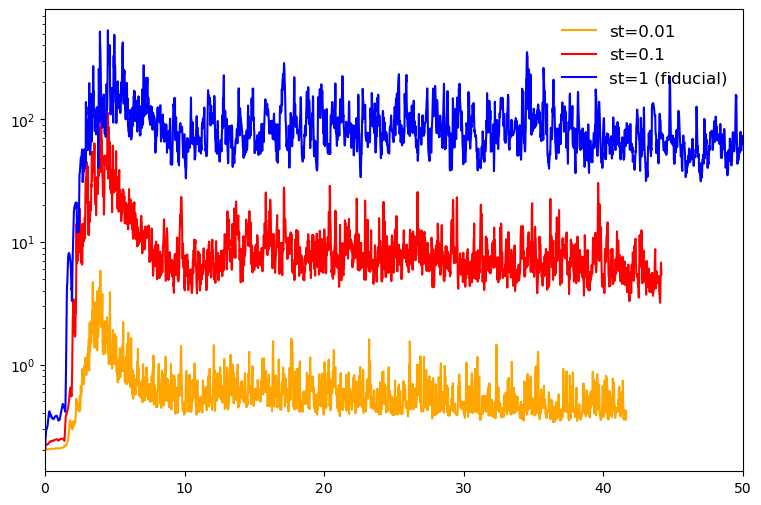

In [14]:
plt.rcParams["figure.figsize"] = (9,6)
fig,ax = plt.subplots(1,1)

directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/dust_parameters/st0.01"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="orange", label = "st=0.01")


###########################################################################################


directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/dust_parameters/st0.1"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="red", label = "st=0.1")


###########################################################################################


directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/noDomainDecomposition"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="blue", label = "st=1 (fiducial)")




ax.legend( loc='best', frameon=False, fontsize=12)

ax.set_yscale('log')
ax.set_xlim(0,50)

(0.0, 50.0)

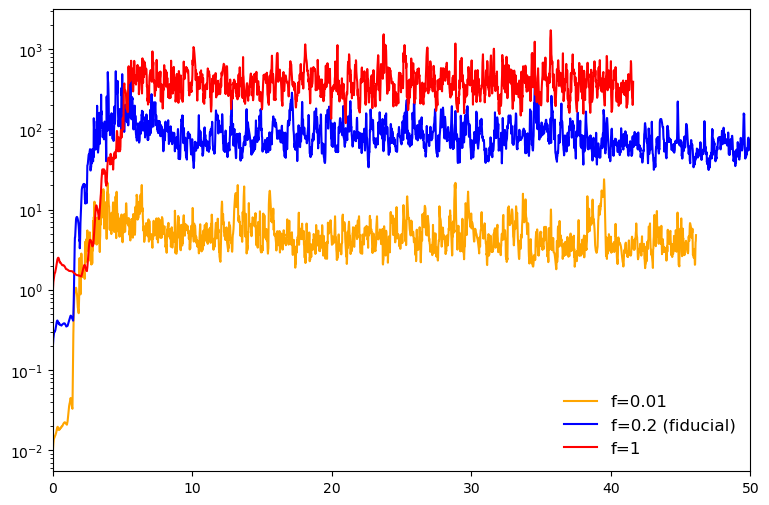

In [15]:
plt.rcParams["figure.figsize"] = (9,6)
fig,ax = plt.subplots(1,1)

directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/dust_parameters/d2g0.01"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="orange", label = "f=0.01")


###########################################################################################


directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/noDomainDecomposition"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="blue", label = "f=0.2 (fiducial)")



###########################################################################################


directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/dust_parameters/d2g1"
time, dens_dust = read_history(directory+"/timevol.dat")
ax.plot(np.multiply(time,1./2./pi),dens_dust,color="red", label = "f=1")





ax.legend( loc='best', frameon=False, fontsize=12)

ax.set_yscale('log')
ax.set_xlim(0,50)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63


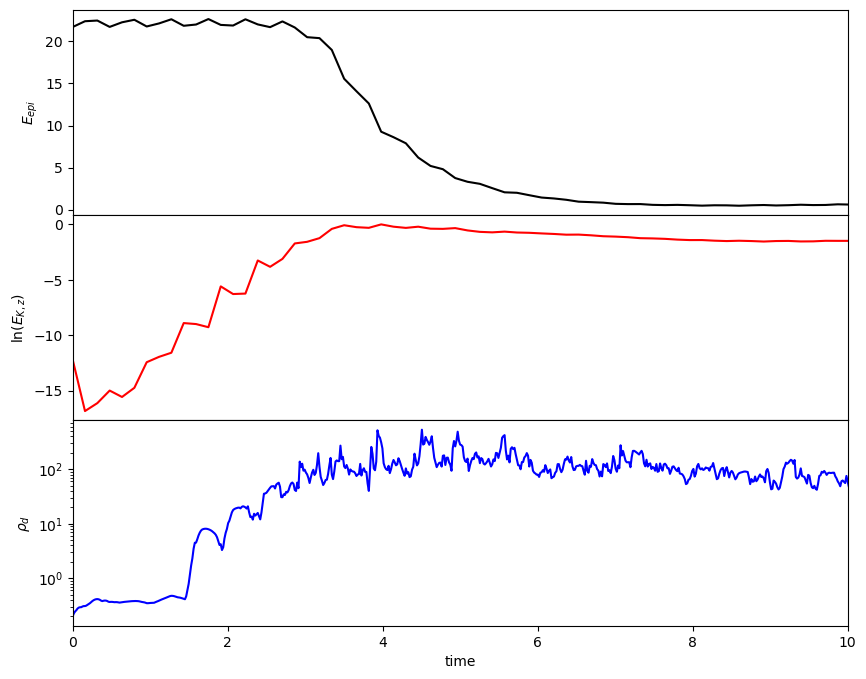

In [63]:
plt.close()

plt.rcParams["figure.figsize"] = (10,8)
fig, axs = plt.subplots(3,1)

#directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/low_detuning"
directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/noDomainDecomposition"

Nx = 4928
Nz= 512

time= linspace(0,63,num=64)
rKE = zeros_like(time)
vKE = zeros_like(time)
for i in range(0,len(time)):
    rKE[i]=calculate_rKE(directory,i,Nx,Nz)
    vKE[i]=calculate_vKE(directory,i,Nx,Nz)
    print(i)
    
data = np.vstack([time,rKE,vKE])
np.savetxt("ke.txt", data.T, delimiter = '   ')


axs[0].plot(np.multiply(time,1./2/pi), rKE,color='black')
axs[1].plot(np.multiply(time,1./2/pi), log(vKE),color='red')
time, dens_dust = read_history(directory+"/timevol.dat")
axs[2].plot(np.multiply(time,1./2./pi),dens_dust,color="blue")


axs[0].set_xlim(0,10)
axs[1].set_xlim(0,10)
axs[2].set_xlim(0,10)

#axs[0].set_yscale("log")
#axs[1].set_yscale("log")
axs[2].set_yscale("log")

axs[0].set_xticks([])
axs[1].set_xticks([])
plt.subplots_adjust(wspace=0.01,hspace=0)
axs[0].set_ylabel(r"$E_{epi}$")
axs[1].set_ylabel(r"$\ln(E_{K,z})$")
axs[2].set_ylabel(r"$\rho_d$")
axs[2].set_xlabel("time")

plt.show()

0.0
0.0006297718394886364
0.0009943974482548702
0.0012528060318587662
0.0007332145393668831
0.0014374968293425325
0.0012991768973214285


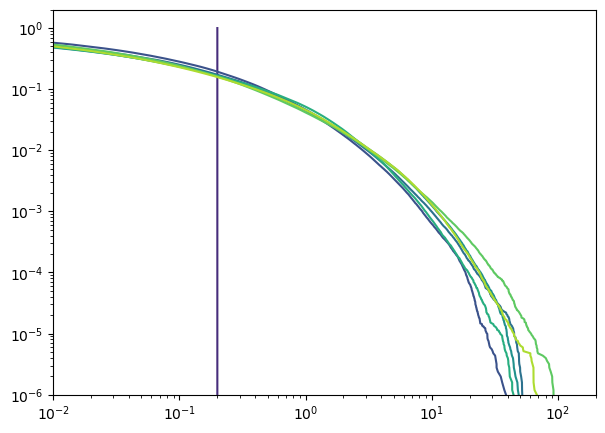

In [203]:
def cdf(file, Nx,Ny,Nz):
    rho_d, vx_d, vy_d, vz_d = read_dust(file, Nx, Ny, Nz)
    rho_d = rho_d.reshape(Nx*Ny*Nz)
    rho_d.sort()
    rho_d = rho_d[::-1]
    p = np.linspace(0, 1, len(rho_d), endpoint=False)
    print(len(rho_d[rho_d>10])/len(rho_d))
    return rho_d, p



plt.close()
plt.rcParams["figure.figsize"] = (7,5)
fig, axs = plt.subplots(1,1)

directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/low_detuning"
directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/noDomainDecomposition"

Nx = 4928
Ny = 1
Nz= 512


times= [0,63,126,188,251,314,377]
col = sns.color_palette("viridis",len(times))
m = 0
for snapshot in times:
    file    = directory + "/data."+ "{:04d}".format(snapshot) + ".vtk"
    rho_d, p = cdf(file, Nx,Ny,Nz)
    axs.plot(rho_d,p, color=col[m])
    m = m+1

axs.set_xscale('log')
axs.set_yscale('log')

axs.set_xlim(0.01,200)
axs.set_ylim(0.000001,2)

plt.show()


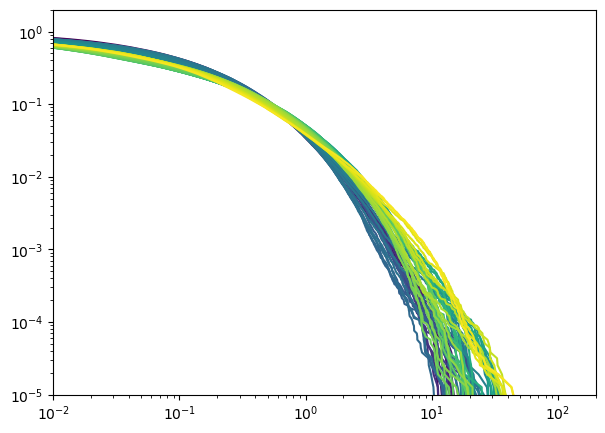

[5.1824776e+01 4.7359192e+01 4.3010910e+01 ... 3.0004607e-08 2.9703225e-08
 2.9663807e-08]
[0.00000000e+00 6.34131494e-06 1.26826299e-05 ... 9.99980976e-01
 9.99987317e-01 9.99993659e-01]


In [7]:
def cdf(file, Nx,Ny,Nz):
    rho_d, vx_d, vy_d, vz_d = read_dust(file, Nx, Ny, Nz)
    rho_d = rho_d.reshape(Nx*Ny*Nz)
    rho_d.sort()
    rho_d = rho_d[::-1]
    p = np.linspace(0, 1, len(rho_d), endpoint=False)
    #print(len(rho_d[rho_d>10])/len(rho_d))
    return rho_d, p


plt.close()
plt.rcParams["figure.figsize"] = (7,5)
fig, axs = plt.subplots(1,1)

directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/low_detuning"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/noDomainDecomposition"

Nx = int(4928/4)
Ny = 1
Nz= int(512/4)


times= linspace(188,251,num=(251-188+1), dtype=int)
col = sns.color_palette("viridis",len(times))
m = 0
temp = np.zeros([int(Nx*Ny*Nz),int(Nx*Ny*Nz),len(times)])
#temp = []*len(times)
for snapshot in times:
    file    = directory + "/data."+ "{:04d}".format(snapshot) + ".vtk"
    rho_d, p = cdf(file, Nx,Ny,Nz)
    axs.plot(rho_d,p, color=col[m])
    #temp[:,m] = p
    m = m+1
#axs.plot(rho_d,temp.mean(axis=1), color="black")
#axs.plot(rho_d,temp[:,1], color="blue")

axs.set_xscale('log')
axs.set_yscale('log')

axs.set_xlim(0.01,200)
axs.set_ylim(0.00001,2)

plt.show()
print(rho_d)
print(p)


60.391987
3.105586534463134e-13
1.107904
0.8892221450805664


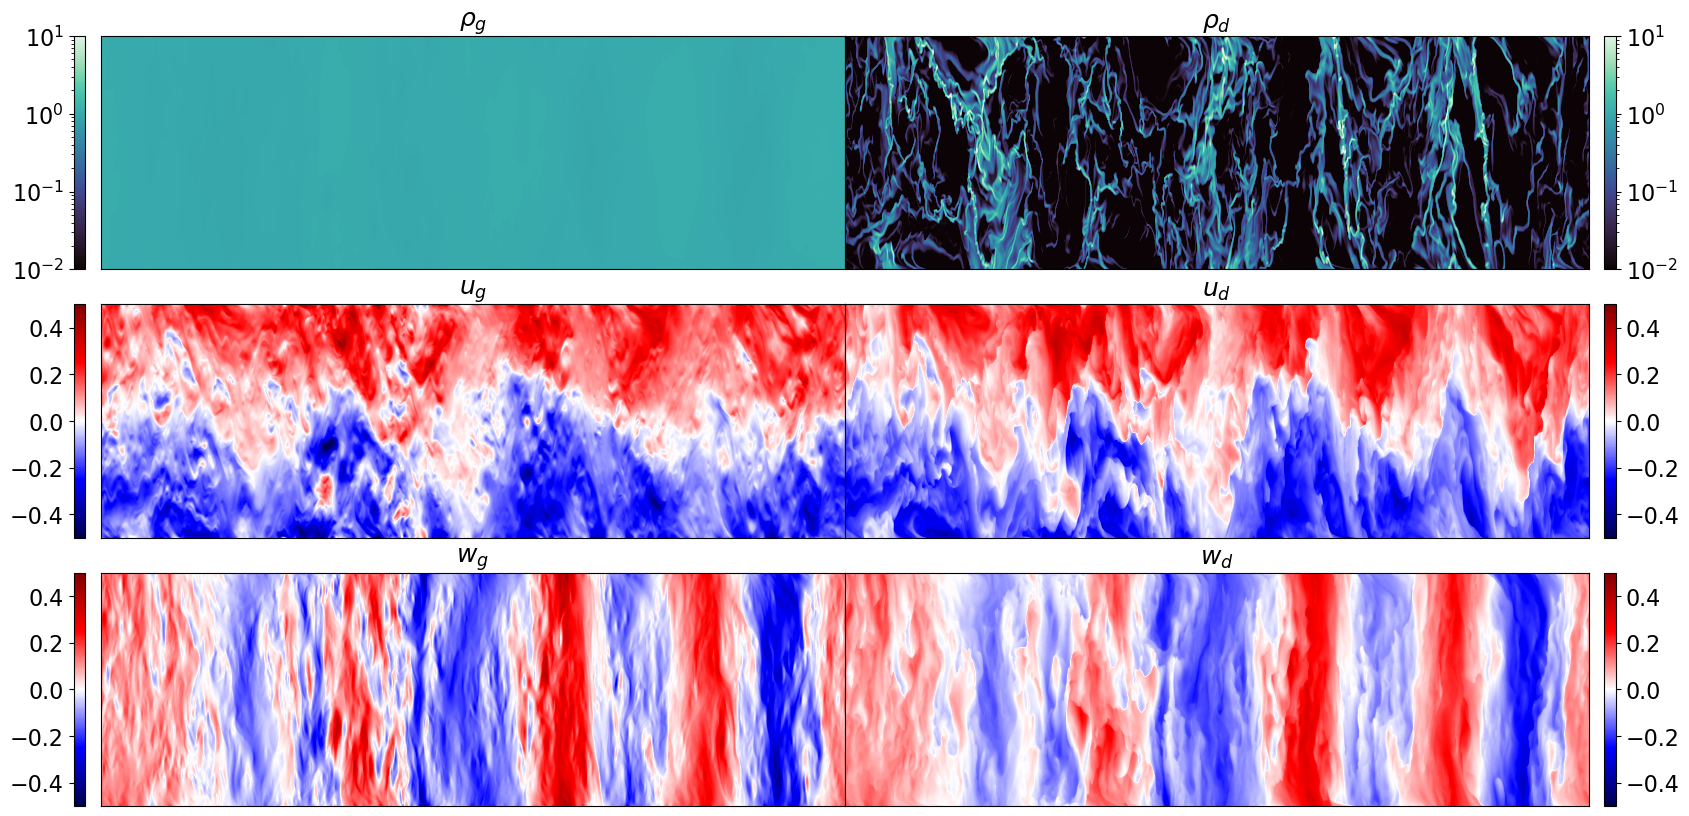

In [41]:
plt.close()
plt.rcParams["figure.figsize"] = (20,10)

fig, axs = plt.subplots(3,2)
plt.subplots_adjust(wspace=0.0,hspace=0.15)


#directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/low_detuning"

directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/noDomainDecomposition"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/psi0.02"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/numerical_parameters/BCs/non_reflective_psi0.02"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/numerical_parameters/BCs/reflective_psi0.02"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/psi0.01"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/psi0.005"

#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/numerical_parameters/BCs/reflective"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/numerical_parameters/BCs/non-reflective"





Nx = 4928
Ny = 1
Nz = 512

snapshot = 126

font = {'family': 'Times New Roman',
        'color':  'black',
        'weight': 'normal',
        'size': 18,
        }

im = read_and_plot_dust_and_gas_integrated_in_y(directory,Nx,Ny,Nz,snapshot,axs,fig, font, vscale=0.5)




plt.show()

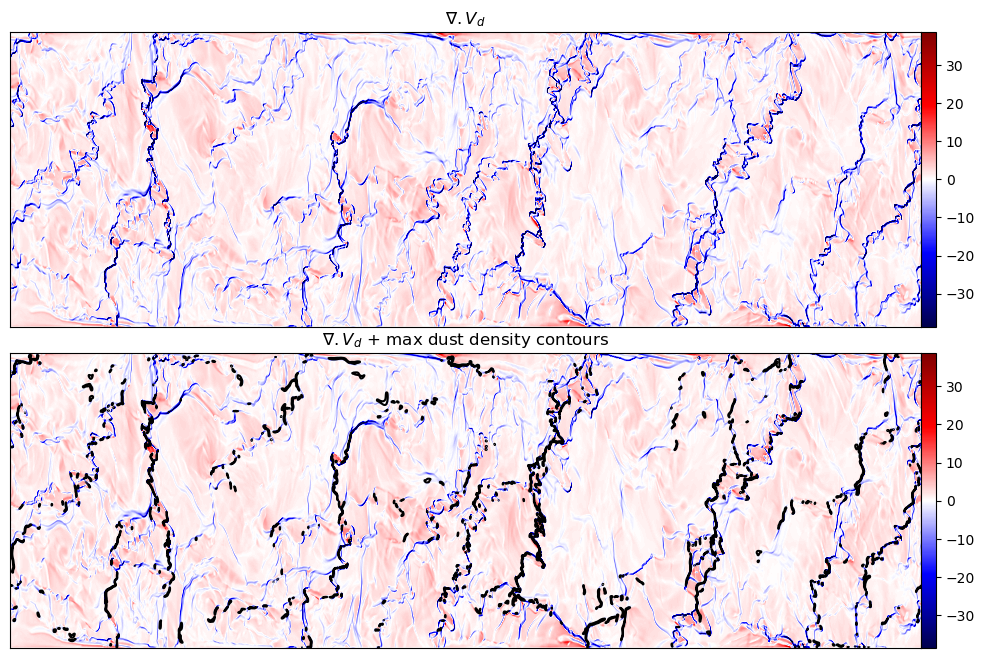

In [167]:
plt.close()
plt.rcParams["figure.figsize"] = (12,8)
fig, axs = plt.subplots(2,1)

#directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/low_detuning"
directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/noDomainDecomposition"

Nx = 4928
Ny = 1
Nz= 512
snapshot = 25


file    = directory + "/data."+ "{:04d}".format(snapshot) + ".vtk"
d = readVTK(file, geometry='cartesian')
rho_g, vx_g, vy_g, vz_g = read_gas(file, Nx, Ny, Nz)
rho_d, vx_d, vy_d, vz_d = read_dust(file, Nx, Ny, Nz)

div_vx_d = zeros_like(vx_d)
div_vz_d = zeros_like(vz_d)
div_v_d = zeros_like(vz_d)

div_vx_g = zeros_like(vx_g)
div_vz_g = zeros_like(vz_g)
div_v_g = zeros_like(vz_g)


dx = 9.66/Nx
dz = 1./Nz
for i in range(1,Nx-1):
    for k in range(1,Nz-1):
        div_vx_d[i,0,k] = (vx_d[i+1,0,k]-vx_d[i-1,0,k])/2/dx
        div_vz_d[i,0,k] = (vz_d[i,0,k+1]-vz_d[i,0,k-1])/2/dz
        div_v_d[i,0,k] = (vx_d[i+1,0,k]-vx_d[i-1,0,k])/2/dx+(vz_d[i,0,k+1]-vz_d[i,0,k-1])/2/dz
        
        div_vx_g[i,0,k] = (vx_g[i+1,0,k]-vx_g[i-1,0,k])/2/dx
        div_vz_g[i,0,k] = (vz_g[i,0,k+1]-vz_g[i,0,k-1])/2/dz
        div_v_g[i,0,k] = (vx_g[i+1,0,k]-vx_g[i-1,0,k])/2/dx+(vz_g[i,0,k+1]-vz_g[i,0,k-1])/2/dz


high = np.max(rho_d[:,0,:])


#im2 = axs.imshow(rho_d[:,0,:].T,origin='lower',norm="log",cmap="mako", aspect='auto', vmin=0.01)
#axs.contour(abs(div_v_d[:,0,:].T), levels=(10.0,100), colors="red")

im0 = axs[0].imshow(div_v_d[:,0,:].T,origin='lower',cmap="seismic", aspect='auto', vmin=0.1*np.min(div_v_d[:,0,:]), vmax= -0.1*np.min(div_v_d[:,0,:]))

im1 = axs[1].imshow(div_v_d[:,0,:].T,origin='lower',cmap="seismic", aspect='auto', vmin=0.1*np.min(div_v_d[:,0,:]), vmax= -0.1*np.min(div_v_d[:,0,:]))
axs[1].contour(rho_d[:,0,:].T, levels=(0.01*high,high),colors="black")
fig.colorbar(im0,location='right', fraction=0.02, pad=0.0)
fig.colorbar(im1,location='right', fraction=0.02, pad=0.0)

axs[0].set_xticks([])
axs[0].set_yticks([])
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[0].set_title(r'$\nabla.V_d$')
axs[1].set_title(r'$\nabla.V_d$ + max dust density contours')

plt.subplots_adjust(wspace=0.01,hspace=0.09)

plt.show()


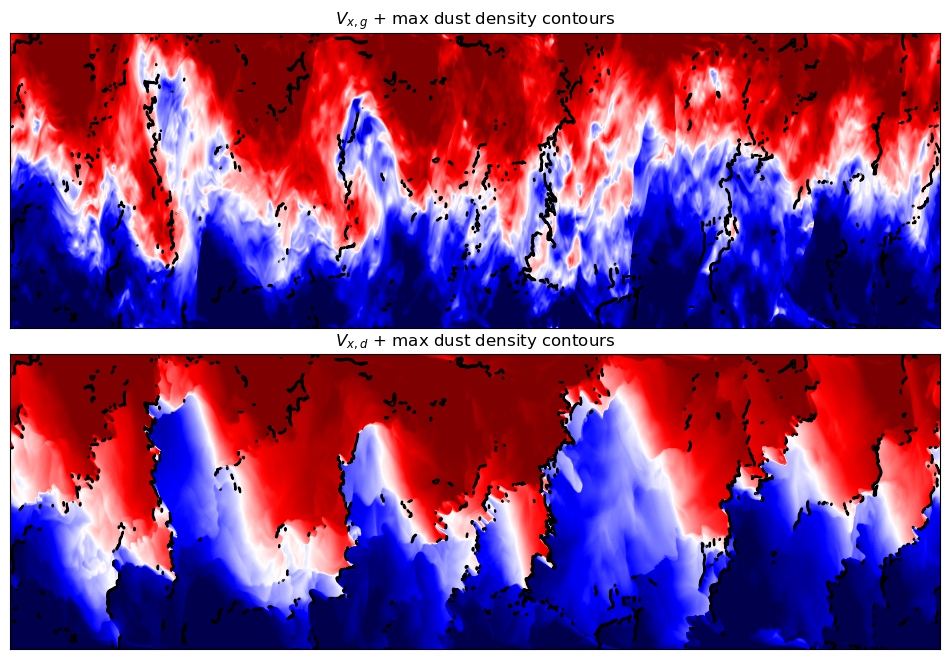

In [168]:
plt.close()
plt.rcParams["figure.figsize"] = (12,8)
fig, axs = plt.subplots(2,1)

#directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/low_detuning"
directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/noDomainDecomposition"

Nx = 4928
Ny = 1
Nz= 512
snapshot = 25

file    = directory + "/data."+ "{:04d}".format(snapshot) + ".vtk"
d = readVTK(file, geometry='cartesian')
rho_g, vx_g, vy_g, vz_g = read_gas(file, Nx, Ny, Nz)
rho_d, vx_d, vy_d, vz_d = read_dust(file, Nx, Ny, Nz)

high = np.max(rho_d[:,0,:])

axs[0].imshow(vx_g[:,0,:].T,origin='lower',cmap="seismic", aspect='auto', vmin=-1.0, vmax=1.0)
axs[0].contour(rho_d[:,0,:].T, levels=(0.01*high,high),colors="black")

axs[1].imshow(vx_d[:,0,:].T,origin='lower',cmap="seismic", aspect='auto', vmin=-1.0, vmax=1.0)
axs[1].contour(rho_d[:,0,:].T, levels=(0.01*high,high),colors="black")

axs[0].set_xticks([])
axs[0].set_yticks([])
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[0].set_title(r'$V_{x,g}$ + max dust density contours')
axs[1].set_title(r'$V_{x,d}$ + max dust density contours')

plt.subplots_adjust(wspace=0.01,hspace=0.09)

plt.show()

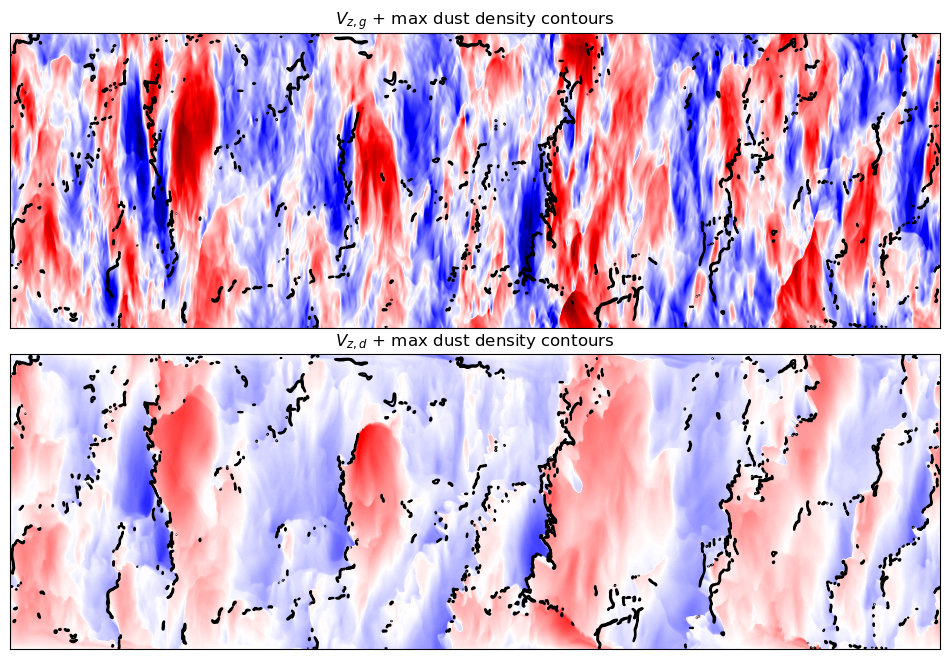

In [169]:
plt.close()
plt.rcParams["figure.figsize"] = (12,8)
fig, axs = plt.subplots(2,1)

#directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/low_detuning"
directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/noDomainDecomposition"

Nx = 4928
Ny = 1
Nz= 512
snapshot = 25

file    = directory + "/data."+ "{:04d}".format(snapshot) + ".vtk"
d = readVTK(file, geometry='cartesian')
rho_g, vx_g, vy_g, vz_g = read_gas(file, Nx, Ny, Nz)
rho_d, vx_d, vy_d, vz_d = read_dust(file, Nx, Ny, Nz)

high = np.max(rho_d[:,0,:])

axs[0].imshow(vz_g[:,0,:].T,origin='lower',cmap="seismic", aspect='auto', vmin=-1.0, vmax=1.0)
axs[0].contour(rho_d[:,0,:].T, levels=(0.01*high,high),colors="black")

axs[1].imshow(vz_d[:,0,:].T,origin='lower',cmap="seismic", aspect='auto', vmin=-1.0, vmax=1.0)
axs[1].contour(rho_d[:,0,:].T, levels=(0.01*high,high),colors="black")

axs[0].set_xticks([])
axs[0].set_yticks([])
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[0].set_title(r'$V_{z,g}$ + max dust density contours')
axs[1].set_title(r'$V_{z,d}$ + max dust density contours')

plt.subplots_adjust(wspace=0.01,hspace=0.09)


plt.show()

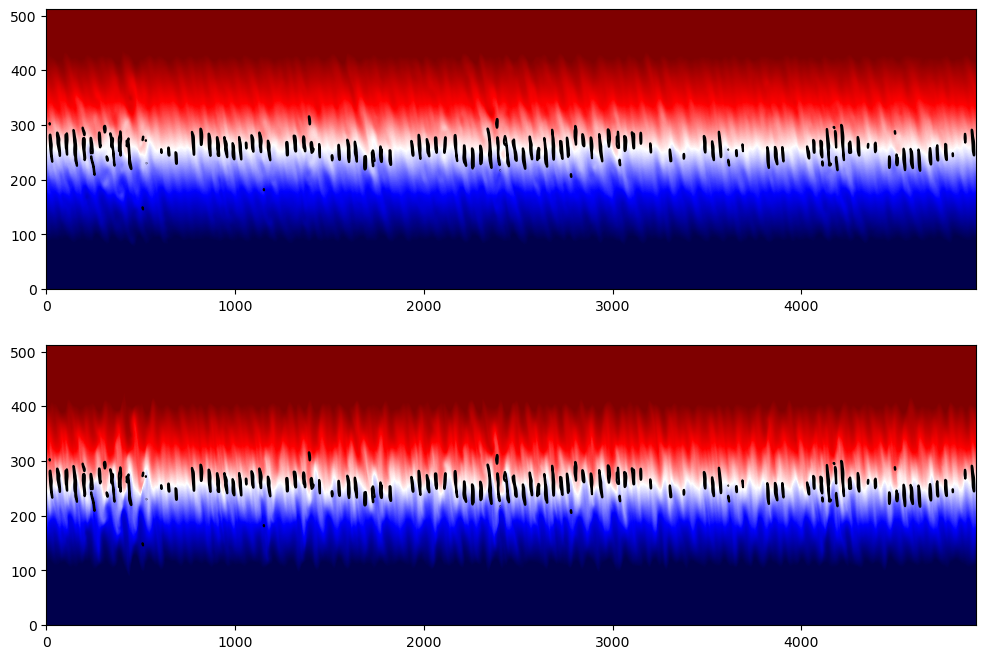

In [90]:
plt.close()
plt.rcParams["figure.figsize"] = (12,8)
fig, axs = plt.subplots(2,1)

#directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/low_detuning"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/noDomainDecomposition"
directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/kappa0.1"

Nx = 4928
Ny = 1
Nz= 512
snapshot = 125

file    = directory + "/data."+ "{:04d}".format(snapshot) + ".vtk"
d = readVTK(file, geometry='cartesian')
rho_g, vx_g, vy_g, vz_g = read_gas(file, Nx, Ny, Nz)
rho_d, vx_d, vy_d, vz_d = read_dust(file, Nx, Ny, Nz)

high = np.max(rho_d[:,0,:])

axs[0].imshow(vx_g[:,0,:].T,origin='lower',cmap="seismic", aspect='auto', vmin=-0.1, vmax=0.1)
axs[0].contour(rho_d[:,0,:].T, levels=(0.1*high,high),colors="black")

axs[1].imshow(vx_d[:,0,:].T,origin='lower',cmap="seismic", aspect='auto', vmin=-0.1, vmax=0.1)
axs[1].contour(rho_d[:,0,:].T, levels=(0.1*high,high),colors="black")


plt.show()

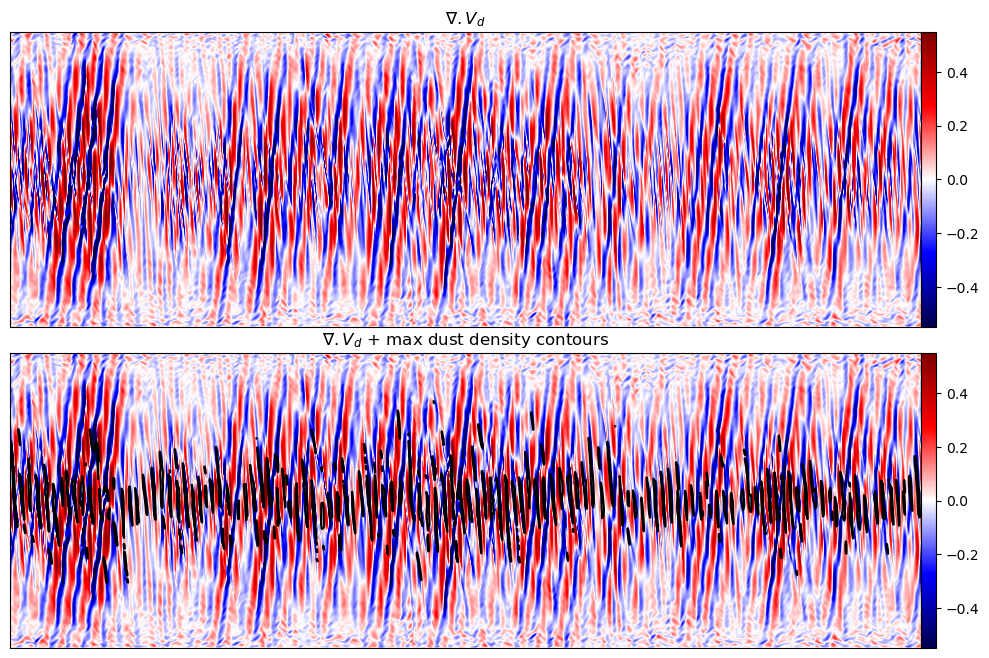

In [174]:
plt.close()
plt.rcParams["figure.figsize"] = (12,8)
fig, axs = plt.subplots(2,1)

#directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/low_detuning"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/noDomainDecomposition"
directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/kappa0.1"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/psi0.02"

Nx = 4928
Ny = 1
Nz= 512
snapshot = 125


file    = directory + "/data."+ "{:04d}".format(snapshot) + ".vtk"
d = readVTK(file, geometry='cartesian')
rho_g, vx_g, vy_g, vz_g = read_gas(file, Nx, Ny, Nz)
rho_d, vx_d, vy_d, vz_d = read_dust(file, Nx, Ny, Nz)

div_vx_d = zeros_like(vx_d)
div_vz_d = zeros_like(vz_d)
div_v_d = zeros_like(vz_d)

div_vx_g = zeros_like(vx_g)
div_vz_g = zeros_like(vz_g)
div_v_g = zeros_like(vz_g)


dx = 9.66/Nx
dz = 1./Nz
for i in range(1,Nx-1):
    for k in range(1,Nz-1):
        div_vx_d[i,0,k] = (vx_d[i+1,0,k]-vx_d[i-1,0,k])/2/dx
        div_vz_d[i,0,k] = (vz_d[i,0,k+1]-vz_d[i,0,k-1])/2/dz
        div_v_d[i,0,k] = (vx_d[i+1,0,k]-vx_d[i-1,0,k])/2/dx+(vz_d[i,0,k+1]-vz_d[i,0,k-1])/2/dz
        
        div_vx_g[i,0,k] = (vx_g[i+1,0,k]-vx_g[i-1,0,k])/2/dx
        div_vz_g[i,0,k] = (vz_g[i,0,k+1]-vz_g[i,0,k-1])/2/dz
        div_v_g[i,0,k] = (vx_g[i+1,0,k]-vx_g[i-1,0,k])/2/dx+(vz_g[i,0,k+1]-vz_g[i,0,k-1])/2/dz


high = np.max(rho_d[:,0,:])


#im2 = axs.imshow(rho_d[:,0,:].T,origin='lower',norm="log",cmap="mako", aspect='auto', vmin=0.01)
#axs.contour(abs(div_v_d[:,0,:].T), levels=(10.0,100), colors="red")

im0 = axs[0].imshow(div_v_d[:,0,:].T,origin='lower',cmap="seismic", aspect='auto', vmin=0.1*np.min(div_v_d[:,0,:]), vmax= -0.1*np.min(div_v_d[:,0,:]))

im1 = axs[1].imshow(div_v_d[:,0,:].T,origin='lower',cmap="seismic", aspect='auto', vmin=0.1*np.min(div_v_d[:,0,:]), vmax= -0.1*np.min(div_v_d[:,0,:]))
axs[1].contour(rho_d[:,0,:].T, levels=(0.05*high,high),colors="black")
fig.colorbar(im0,location='right', fraction=0.02, pad=0.0)
fig.colorbar(im1,location='right', fraction=0.02, pad=0.0)

axs[0].set_xticks([])
axs[0].set_yticks([])
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[0].set_title(r'$\nabla.V_d$')
axs[1].set_title(r'$\nabla.V_d$ + max dust density contours')

plt.subplots_adjust(wspace=0.01,hspace=0.09)

plt.show()

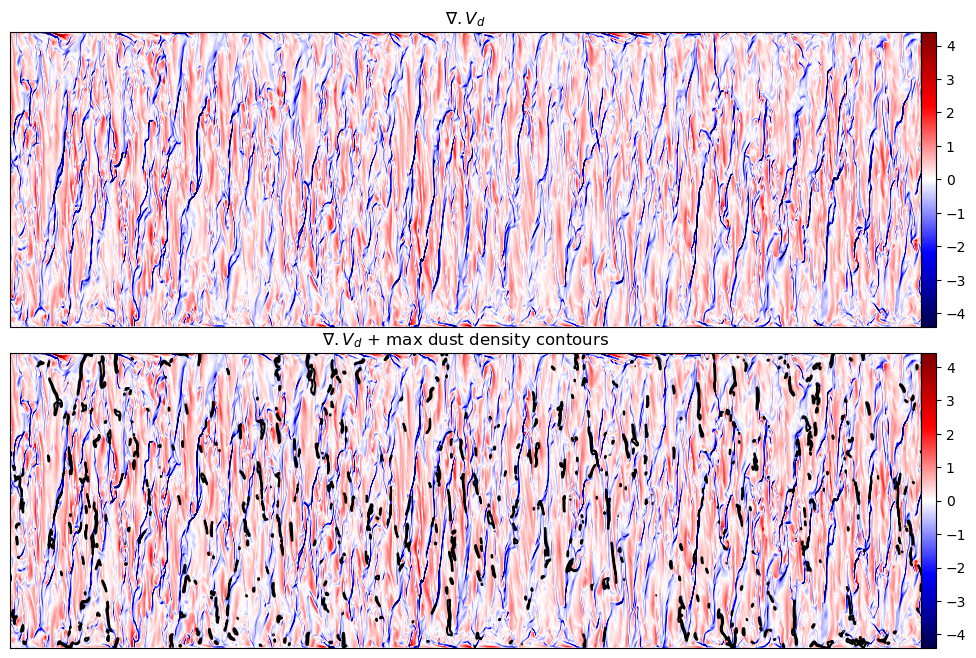

In [176]:
plt.close()
plt.rcParams["figure.figsize"] = (12,8)
fig, axs = plt.subplots(2,1)

#directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/low_detuning"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/noDomainDecomposition"
directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/kappa0.1"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/psi0.02"

Nx = 4928
Ny = 1
Nz= 512
snapshot = 251


file    = directory + "/data."+ "{:04d}".format(snapshot) + ".vtk"
d = readVTK(file, geometry='cartesian')
rho_g, vx_g, vy_g, vz_g = read_gas(file, Nx, Ny, Nz)
rho_d, vx_d, vy_d, vz_d = read_dust(file, Nx, Ny, Nz)

div_vx_d = zeros_like(vx_d)
div_vz_d = zeros_like(vz_d)
div_v_d = zeros_like(vz_d)

div_vx_g = zeros_like(vx_g)
div_vz_g = zeros_like(vz_g)
div_v_g = zeros_like(vz_g)


dx = 9.66/Nx
dz = 1./Nz
for i in range(1,Nx-1):
    for k in range(1,Nz-1):
        div_vx_d[i,0,k] = (vx_d[i+1,0,k]-vx_d[i-1,0,k])/2/dx
        div_vz_d[i,0,k] = (vz_d[i,0,k+1]-vz_d[i,0,k-1])/2/dz
        div_v_d[i,0,k] = (vx_d[i+1,0,k]-vx_d[i-1,0,k])/2/dx+(vz_d[i,0,k+1]-vz_d[i,0,k-1])/2/dz
        
        div_vx_g[i,0,k] = (vx_g[i+1,0,k]-vx_g[i-1,0,k])/2/dx
        div_vz_g[i,0,k] = (vz_g[i,0,k+1]-vz_g[i,0,k-1])/2/dz
        div_v_g[i,0,k] = (vx_g[i+1,0,k]-vx_g[i-1,0,k])/2/dx+(vz_g[i,0,k+1]-vz_g[i,0,k-1])/2/dz


high = np.max(rho_d[:,0,:])


#im2 = axs.imshow(rho_d[:,0,:].T,origin='lower',norm="log",cmap="mako", aspect='auto', vmin=0.01)
#axs.contour(abs(div_v_d[:,0,:].T), levels=(10.0,100), colors="red")

im0 = axs[0].imshow(div_v_d[:,0,:].T,origin='lower',cmap="seismic", aspect='auto', vmin=0.1*np.min(div_v_d[:,0,:]), vmax= -0.1*np.min(div_v_d[:,0,:]))

im1 = axs[1].imshow(div_v_d[:,0,:].T,origin='lower',cmap="seismic", aspect='auto', vmin=0.1*np.min(div_v_d[:,0,:]), vmax= -0.1*np.min(div_v_d[:,0,:]))
axs[1].contour(rho_d[:,0,:].T, levels=(0.005*high,high),colors="black")
fig.colorbar(im0,location='right', fraction=0.02, pad=0.0)
fig.colorbar(im1,location='right', fraction=0.02, pad=0.0)

axs[0].set_xticks([])
axs[0].set_yticks([])
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[0].set_title(r'$\nabla.V_d$')
axs[1].set_title(r'$\nabla.V_d$ + max dust density contours')

plt.subplots_adjust(wspace=0.01,hspace=0.09)

plt.show()

0.0
0.0
1.0700968952922078e-05
1.030463676948052e-05
5.5090173498376625e-05
0.00014743557224025975
0.00016764851359577922


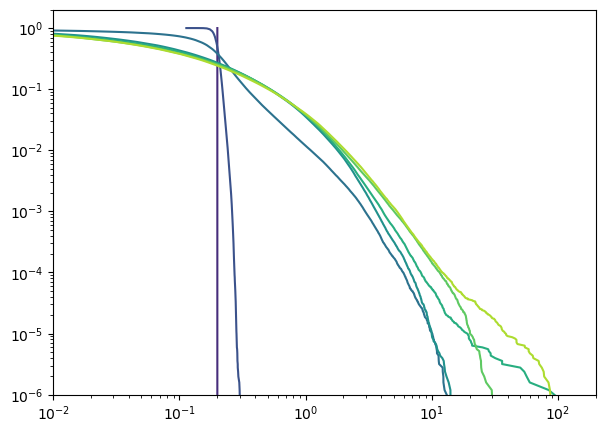

In [146]:
def cdf(file, Nx,Ny,Nz):
    rho_d, vx_d, vy_d, vz_d = read_dust(file, Nx, Ny, Nz)
    rho_d = rho_d.reshape(Nx*Ny*Nz)
    rho_d.sort()
    rho_d = rho_d[::-1]
    p = np.linspace(0, 1, len(rho_d), endpoint=False)
    print(len(rho_d[rho_d>10])/len(rho_d))
    return rho_d, p



plt.close()
plt.rcParams["figure.figsize"] = (7,5)
fig, axs = plt.subplots(1,1)

#directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/low_detuning"
#directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/noDomainDecomposition"
directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/kappa0.1"

Nx = 4928
Ny = 1
Nz= 512


times= [0,63,126,188,251,314,364]
col = sns.color_palette("viridis",len(times))
m = 0
for snapshot in times:
    file    = directory + "/data."+ "{:04d}".format(snapshot) + ".vtk"
    rho_d, p = cdf(file, Nx,Ny,Nz)
    axs.plot(rho_d,p, color=col[m])
    m = m+1

axs.set_xscale('log')
axs.set_yscale('log')

axs.set_xlim(0.01,200)
axs.set_ylim(0.000001,2)

plt.show()


In [62]:
data = np.vstack([time,rKE,vKE])
print(data.T)
print(rKE)
np.savetxt("ke.txt", data.T, delimiter = '   ')


[[0.00000000e+00 2.17087935e+01 5.05734796e-06]
 [1.00000000e+00 2.23967792e+01 4.81299348e-08]
 [2.00000000e+00 2.24784133e+01 9.84085321e-08]
 [3.00000000e+00 2.17224678e+01 3.05766871e-07]]
[21.70879349 22.39677919 22.47841328 21.72246785]


(1e-06, 1.2)

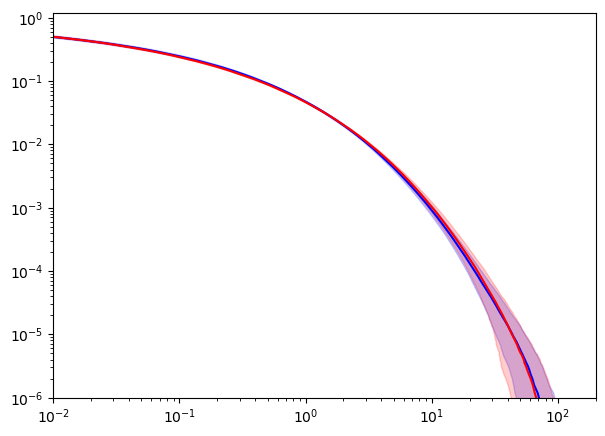

In [136]:
def cdf(file, Nx,Ny,Nz):
    rho_d, vx_d, vy_d, vz_d = read_dust(file, Nx, Ny, Nz)
    rho_d = rho_d.reshape(Nx*Ny*Nz)
    rho_d.sort()
    rho_d = rho_d[::-1]
    p = np.linspace(0, 1, len(rho_d), endpoint=False)
    #print(len(rho_d[rho_d>10])/len(rho_d))
    return rho_d, p

def plot_cdf(times, directory, axs, colour, Nx, Ny, Nz):
    m = 0
    all_data = []
    for snapshot in times:
        file    = directory + "/data."+ "{:04d}".format(snapshot) + ".vtk"
        rho_d, p = cdf(file, Nx,Ny,Nz)
        
        all_data.append(rho_d)
        m = m+1
    avg = np.average(all_data,axis=0)
    std = np.std(all_data,axis=0)
    axs.plot(avg,p,color=colour)
    axs.fill_betweenx(p,avg-std,avg+std,color=colour,alpha=0.2)


plt.close()
plt.rcParams["figure.figsize"] = (7,5)
fig, axs = plt.subplots(1,1)

#directory = "/Users/haly/science/projects/local_warp/shear_2D/reverse_periodic/low_detuning"
directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/fiducial/noDomainDecomposition"

Nx = int(4928/1)
Ny = 1
Nz= int(512/1)


#times= linspace(64,126,num=int((126-64+1)/1), dtype=int)
#plot_cdf(times,directory,axs,"red",Nx,Ny,Nz)

#times= linspace(127,188,num=int((188-127+1)/1), dtype=int)
#plot_cdf(times,directory,axs,"green",Nx,Ny,Nz)

times= linspace(189,251,num=int((251-189+1)/1), dtype=int)
plot_cdf(times,directory,axs,"blue",Nx,Ny,Nz)

#times= linspace(252,314,num=int((314-252+1)/1), dtype=int)
#plot_cdf(times,directory,axs,"cyan",Nx,Ny,Nz)

#times= linspace(315,377,num=int((377-314+1)/1), dtype=int)
#plot_cdf(times,directory,axs,"black",Nx,Ny,Nz)

directory = "/Volumes/staff-umbrella/datahaly/idefix/local_warp/sweep/warp_parameters/no_feedback"
plot_cdf(times,directory,axs,"red",Nx,Ny,Nz)


axs.set_xscale('log')
axs.set_yscale('log')

axs.set_xlim(0.01,200)
axs.set_ylim(0.000001,1.2)
#print(all_data)


In [46]:
from statsmodels.distributions.empirical_distribution import ECDF

ecdf = ECDF(rho_d)
print(ecdf(rho_d)) # Gives probability of data <= 3.0

[0.62577998 0.66662439 0.68795023 ... 0.78310166 0.88441685 0.85323027]
